<br/><br/>
<center><span style="font-size: 40pt; font-weight: bold">Être ou ne pas être ?</span></center>
<br/>
<center><span style="font-size: 22pt; font-weight: bold">Survival Classification on Imbalanced Clinical Data :<br/>Feature Engineering, Dimensionality Reduction and Model Selection</span></center>

---

# Name

* 

# Présentation du challenge

## La question principale de ce challenge est :

* Comment prédire la survie d'un·e patient·e compte tenu de son dossier médical ?
* Plus précisément, prédire si le·la patient·e décède pendant son séjour à l'hôpital.

## Données

- **79 999 patients** dans le jeu d'entraînement, **20 000** dans le jeu de test
- **341 variables** : 226 numériques, 107 binaires, 8 catégorielles
- **Label** : `DIED` (0 = survie, 1 = décès)
- **Déséquilibre** : 2 797 décès (3.5%) vs 77 202 survivants (96.5%)

Références : Isabelle Guyon, Kristin Bennett, Andrew Yale, Adrien Pavao, Thomas Gerspacher

## Évaluation

| Critère | Points |
|---|---|
| Compréhension et analyse exploratoire | 4 |
| Code propre et documenté | 4 |
| Qualité du modèle (sélection + hyperparamètres) | 4 |
| Évaluation des performances | 4 |
| Présentation orale | 4 |
| **Bonus** : gagnant/e du challenge | 1 |

Note: 18/20

---
# Challenge
## 0. Imports et configuration

In [1]:
from datetime import datetime
from pathlib import Path

import imblearn
import imblearn.pipeline
import imblearn.over_sampling
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler, SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn import (
    decomposition,
    ensemble,
    linear_model,
    metrics,
    model_selection,
    naive_bayes,
    pipeline,
    preprocessing,
    svm,
)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


print("Imports OK")

Imports OK


In [2]:
%reload_ext autoreload
%autoreload 2
%config InlineBackend.figure_format="retina"

np.set_printoptions(precision=3, suppress=True)
pd.options.display.float_format = "{:,.3g}".format

#On fixe une graine aléatoire pour assurer la reproductibilité des résultats
RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="muted")

## 1. Compréhension du problème

### Explication de la tâche

Il s'agit d'un problème de **classification binaire supervisée** : à partir du dossier médical d'un·e patient·e (341 variables), prédire la variable `DIED` (0 = survie, 1 = décès pendant le séjour).

Le pipeline suivi est :
1. **Chargement** des données (format espace-séparé, sans header)
2. **Exploration** : types de variables, déséquilibre, valeurs manquantes
3. **Préparation** : encodage des catégorielles, imputation, One-Hot Encoding
4. **Rééquilibrage** : RandomOverSampler / SMOTE pour compenser les 3.5% de décès
5. **Modélisation** : StandardScaler → PCA → Classifieur
6. **Évaluation** : balanced accuracy, recall, AUC-ROC, matrice de confusion
7. **Export** des prédictions pour soumission sur Codalab

### Pourquoi `balanced_accuracy_score` ?

Le jeu de données est fortement **déséquilibré** : 96.5% de survivants. Un modèle naïf prédisant toujours la survie obtiendrait 96.5% d'accuracy — sans rien apprendre.

La **balanced accuracy** est la moyenne des rappels par classe :
$$\text{balanced\_accuracy} = \frac{1}{2}\left(\frac{TP}{TP+FN} + \frac{TN}{TN+FP}\right)$$

Elle vaut **0.5** pour un classifieur aléatoire et **1.0** pour un classifieur parfait, indépendamment du déséquilibre.

## 2. Chargement des données

In [3]:
from pathlib import Path
print(Path().cwd())

/home/imal/ICU-Survival-Prediction-End-to-End-ML-Pipeline/src


In [4]:
# Chemin vers les données 
DATA = Path("/home/imal/ICU-Survival-Prediction-End-to-End-ML-Pipeline/data/public_data")
PRED_PATH = Path("Submissions")

assert DATA.is_dir(), (
    f"Repertoire '{DATA}' introuvable. "
    "Placez les fichiers du challenge dans un dossier 'public_data/' "
    "au meme niveau que ce notebook."
)
print(f"Donnees trouvees : {DATA.resolve()}")

Donnees trouvees : /home/imal/ICU-Survival-Prediction-End-to-End-ML-Pipeline/data/public_data


In [5]:
df = pd.read_csv(DATA / "mimic_synthetic_train.data", sep=r"\s+", header=None)
print(df.columns)
df.head()

/tmp/ipykernel_260814/2841389418.py:1: DtypeWarning: Columns (59) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA / "mimic_synthetic_train.data", sep=r"\s+", header=None)


Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       332, 333, 334, 335, 336, 337, 338, 339, 340, 341],
      dtype='int64', length=342)


,0,1,2,3,4,5,6,7,8,9,...,332,333,334,335,336,337,338,339,340,341
0,0,45524,108398,2128-05-15_23:42:00,2132-07-23_15:00:00,Private,ENGL,CATHOLIC,DIVORCED,WHITE,...,0,0,0,0,0,0,0,0,0,0
1,1,50520,186416,2134-03-17_03:59:00,2113-03-06_12:05:00,Private,ENGL,UNOBTAINABLE,SINGLE,WHITE,...,0,0,0,0,0,0,0,0,0,1
2,2,17956,126413,2164-04-05_17:32:00,2180-09-20_16:30:00,Medicaid,SPAN,CATHOLIC,WIDOWED,OTHER,...,0,0,0,0,0,0,0,0,0,0
3,3,90258,109355,2102-09-08_00:58:00,2166-06-26_15:30:00,Medicare,ENGL,NOT_SPECIFIED,MARRIED,WHITE,...,0,0,0,0,0,0,0,0,1,0
4,4,25159,123784,2163-08-06_12:07:00,2147-01-14_18:40:00,Medicare,ENGL,UNOBTAINABLE,MARRIED,UNKNOWN/NOT_SPECIFIED,...,0,0,0,0,0,0,0,0,0,0


In [6]:
# Variables identifiantes et temporelles : non pertinentes pour la prédiction (les 4 premières colonnes)
DROP_VARS = ["ADMITTIME", "DISCHTIME", "SUBJECT_ID", "HADM_ID"]

In [7]:
# Chargement des métadonnées
features = pd.read_csv(
    DATA / "mimic_synthetic_feat.name", header=None
).values.flatten()  # 341 noms de variables

labels = pd.read_csv(
    DATA / "mimic_synthetic_label.name", header=None
).values.flatten()  # ['DIED']

types = pd.read_csv(
    DATA / "mimic_synthetic_feat.type", header=None
).set_index(features)[0]  # Numerical / Binary / Categorical

print(f"{len(features)} variables chargees")
print(f"Label : {labels}")
print(f"Types : {types.value_counts().to_dict()}")

341 variables chargees
Label : ['DIED']
Types : {'Numerical': 226, 'Binary': 107, 'Categorical': 8}


In [8]:
# Chargement du jeu d'entraînement
# Format : valeurs separees par des espaces, pas de header, 1 ligne = 1 patient
x_df = pd.read_csv(
    DATA / "mimic_synthetic_train.data",
    header=None,
    names=features,
    sep=" ",
)
x_df.drop(columns=DROP_VARS, inplace=True)

# Labels (0 = survie, 1 = deces)
ys = pd.read_csv(
    DATA / "mimic_synthetic_train.solution",
    header=None,
    names=labels,
    sep=" ",
)["DIED"]

print(f"Train : {x_df.shape[0]:,} patients x {x_df.shape[1]} variables")
print(f"  Deces : {ys.sum():,} ({ys.mean():.1%})  |  Survie : {(ys==0).sum():,} ({(ys==0).mean():.1%})")

Train : 79,999 patients x 337 variables
  Deces : 2,797 (3.5%)  |  Survie : 77,202 (96.5%)


In [9]:
# Chargement du jeu de test (sans labels — a predire)
x_test_df = pd.read_csv(
    DATA / "mimic_synthetic_test.data",
    header=None,
    names=features,
    sep=" ",
)
x_test_df.drop(columns=DROP_VARS, inplace=True)

print(f"Test  : {x_test_df.shape[0]:,} patients x {x_test_df.shape[1]} variables")

Test  : 20,001 patients x 337 variables


## 3. Analyse exploratoire

### 3.1 Types des variables

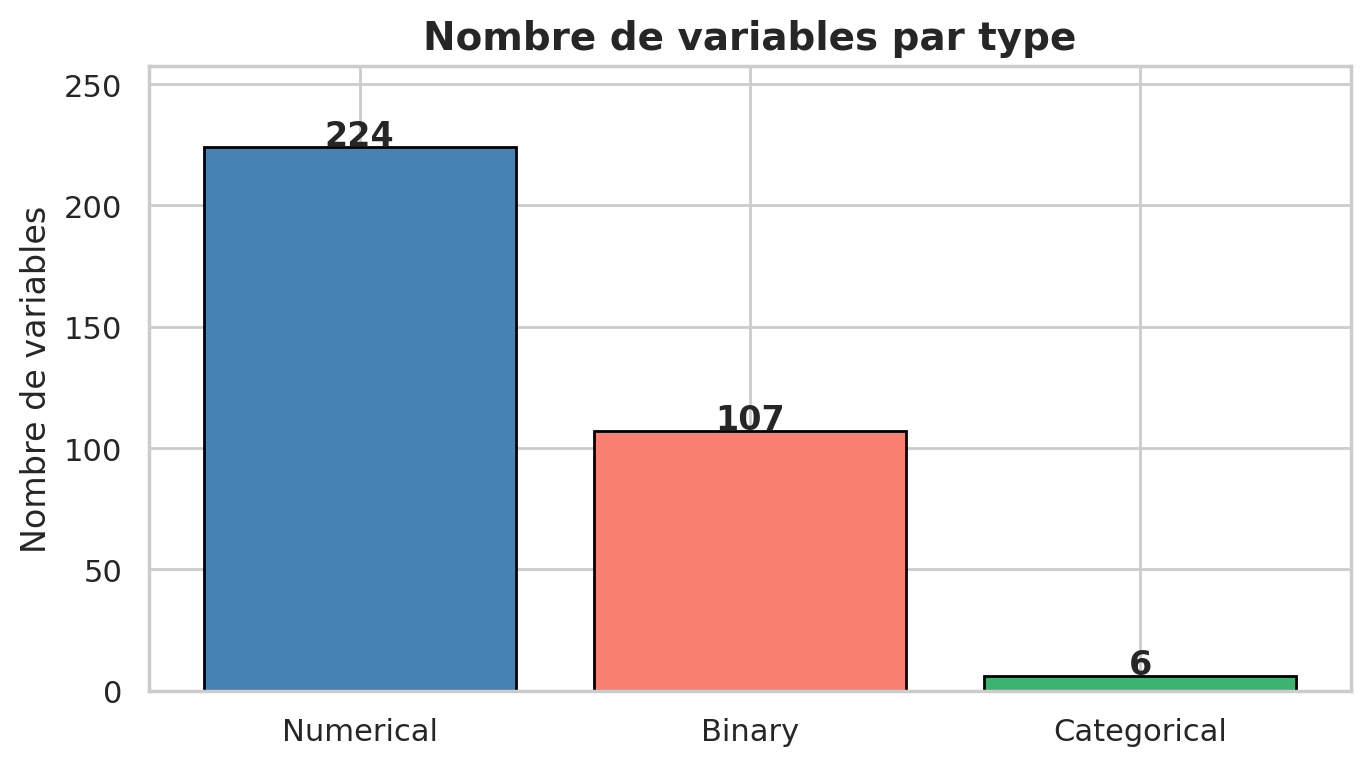

0
Numerical      224
Binary         107
Categorical      6


In [10]:
remaining_features = [f for f in features if f not in DROP_VARS]
types_filtered = types[remaining_features]
type_counts = types_filtered.value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["steelblue", "salmon", "mediumseagreen"]
bars = ax.bar(type_counts.index, type_counts.values, color=colors, edgecolor="black")
for bar, v in zip(bars, type_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, str(v),
            ha="center", fontweight="bold", fontsize=12)
ax.set_title("Nombre de variables par type", fontsize=14, fontweight="bold")
ax.set_ylabel("Nombre de variables")
ax.set_ylim(0, type_counts.max() * 1.15)
plt.tight_layout()
plt.show()

print(type_counts.to_string())

### 3.2 Distribution de la variable cible

Le jeu de données est fortement **déséquilibré** : seulement **3.5% de décès**. C'est ce déséquilibre qui justifie l'usage de la `balanced_accuracy` et des techniques de rééquilibrage.

Statistiques de la variable cible (DIED) :
count   8e+04
mean    0.035
std     0.184
min         0
25%         0
50%         0
75%         0
max         1
Name: DIED, dtype: float64


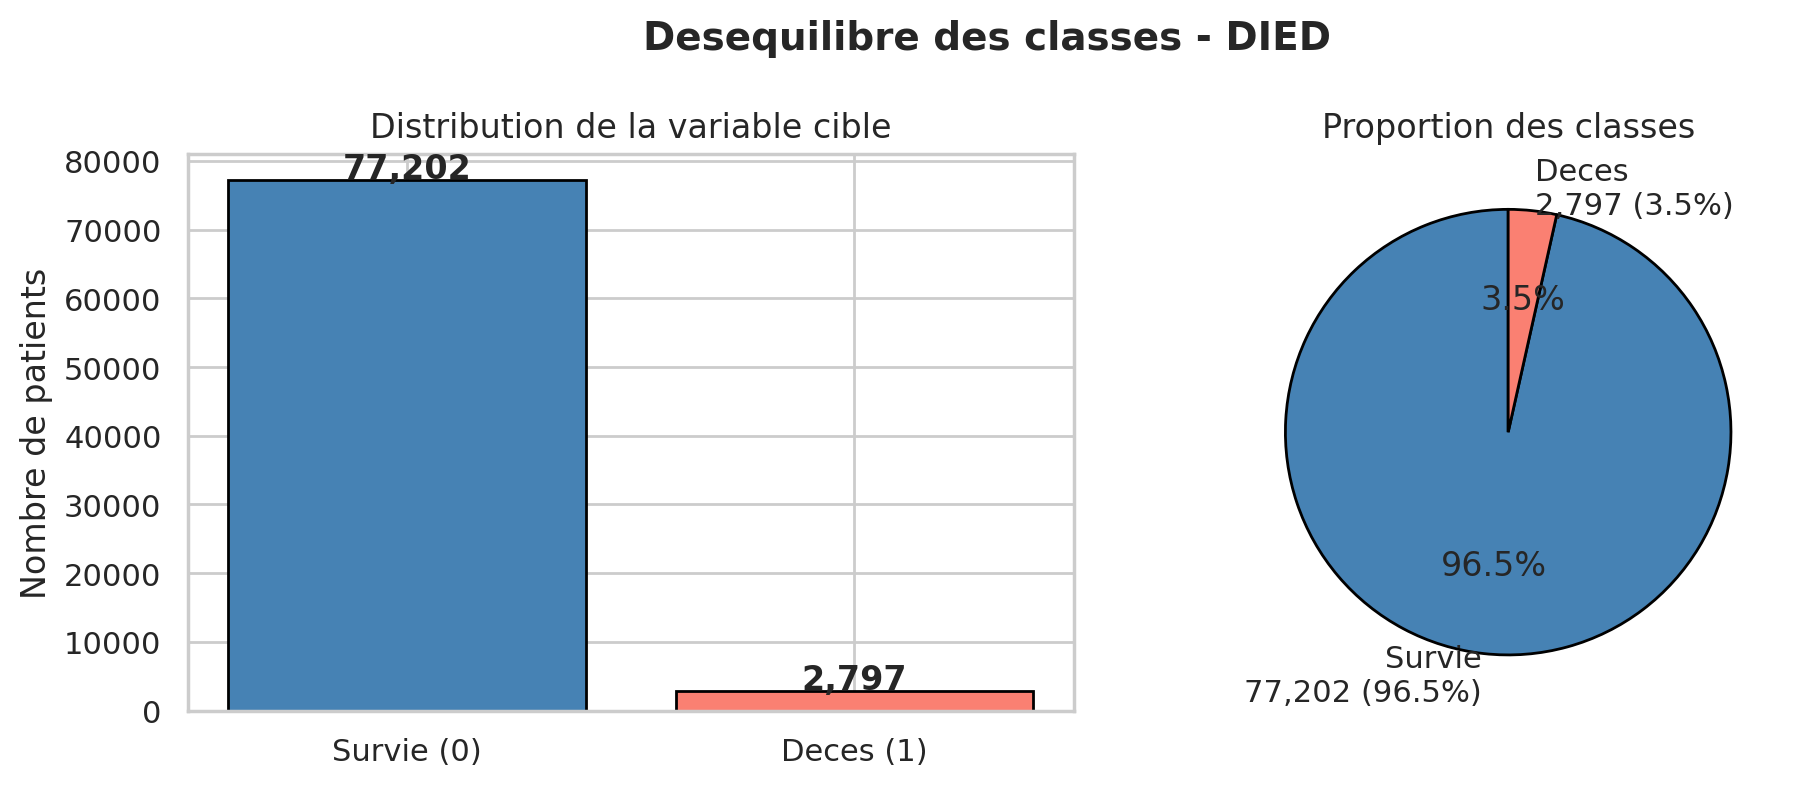

In [11]:
print("Statistiques de la variable cible (DIED) :")
print(ys.describe())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = ys.value_counts().sort_index()
axes[0].bar(["Survie (0)", "Deces (1)"], counts.values,
            color=["steelblue", "salmon"], edgecolor="black")
axes[0].set_title("Distribution de la variable cible")
axes[0].set_ylabel("Nombre de patients")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 300, f"{v:,}", ha="center", fontweight="bold")

axes[1].pie(
    counts.values,
    labels=[f"Survie\n{counts[0]:,} (96.5%)", f"Deces\n{counts[1]:,} (3.5%)"],
    colors=["steelblue", "salmon"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(edgecolor="black")
)
axes[1].set_title("Proportion des classes")

plt.suptitle("Desequilibre des classes - DIED", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.3 Valeurs manquantes

In [12]:
missing = x_df.isnull().sum()
n_missing_cols = (missing > 0).sum()
total_missing  = missing.sum()

print(f"Colonnes avec valeurs manquantes : {n_missing_cols}")
print(f"Total de valeurs manquantes      : {total_missing:,}")

if n_missing_cols > 0:
    top_missing = (
        pd.DataFrame({"Nb manquants": missing, "Pct (%)": missing / len(x_df) * 100})
        .query("`Nb manquants` > 0")
        .sort_values("Pct (%)", ascending=False)
    )
    print("\nTop 10 colonnes avec le plus de valeurs manquantes :")
    print(top_missing.head(10).to_string())
else:
    print("Aucune valeur manquante dans le jeu d'entrainement.")

Colonnes avec valeurs manquantes : 6
Total de valeurs manquantes      : 13

Top 10 colonnes avec le plus de valeurs manquantes :
                                    Nb manquants  Pct (%)
ECodes:Adverseeffectsofmedicalcare             6   0.0075
ICU                                            2   0.0025
Otnutritdx                                     2   0.0025
LANGUAGE                                       1  0.00125
MARITAL_STATUS                                 1  0.00125
Othnervdx                                      1  0.00125


## 3.4 Sélection des variables par corrélation

Avant tout encodage ou modélisation, nous analysons la **corrélation point-bisériale** entre chaque variable et la cible `DIED`.

**Critère de suppression** : corrélation < 0.01 ET p-value > 0.05.

**Nuance importante** : ce projet vise à créer un modèle prédictif généralisable à de nouveaux patients — pas uniquement à ce dataset. Nous appliquons donc deux niveaux de décision :

1. **Variables catégorielles** : suppression si signal nul ET pas de justification clinique pour la mortalité hospitalière.
2. **Variables numériques/binaires** : conservation de toutes — elles représentent des comorbidités et constantes vitales dont la pertinence clinique est reconnue, même si leur corrélation individuelle est faible sur ce dataset synthétique (GAN).

In [13]:
cat_cols = x_df.select_dtypes(include="object").columns.tolist()
print(f"Variables categorielles ({len(cat_cols)}) : {cat_cols}\n")

for col in cat_cols:
    n = x_df[col].nunique()
    top = x_df[col].value_counts().head(5)
    print(f"  {col} ({n} modalites) — top 5 : {top.to_dict()}")

Variables categorielles (7) : ['INSURANCE', 'LANGUAGE', 'RELIGION', 'MARITAL_STATUS', 'ETHNICITY', 'GENDER', 'ICU']

  INSURANCE (5 modalites) — top 5 : {'Medicare': 44670, 'Private': 23964, 'Medicaid': 6434, 'Government': 2933, 'Self_Pay': 1998}
  LANGUAGE (68 modalites) — top 5 : {'ENGL': 75733, 'SPAN': 871, 'RUSS': 582, 'PTUN': 554, 'CANT': 306}
  RELIGION (20 modalites) — top 5 : {'CATHOLIC': 30384, 'NOT_SPECIFIED': 15110, 'UNOBTAINABLE': 8761, 'PROTESTANT_QUAKER': 8706, 'JEWISH': 7399}
  MARITAL_STATUS (7 modalites) — top 5 : {'MARRIED': 43661, 'SINGLE': 18318, 'WIDOWED': 9375, 'DIVORCED': 5015, 'UNKNOWN_(DEFAULT)': 2114}
  ETHNICITY (41 modalites) — top 5 : {'WHITE': 59728, 'UNKNOWN/NOT_SPECIFIED': 4343, 'BLACK/AFRICAN_AMERICAN': 3718, 'OTHER': 1647, 'HISPANIC_OR_LATINO': 1429}
  GENDER (2 modalites) — top 5 : {'M': 46425, 'F': 33574}
  ICU (5 modalites) — top 5 : {'MICU': 27780, 'CSRU': 16789, 'SICU': 12803, 'CCU': 11770, 'TSICU': 10855}


### 3.4.1 Variables catégorielles

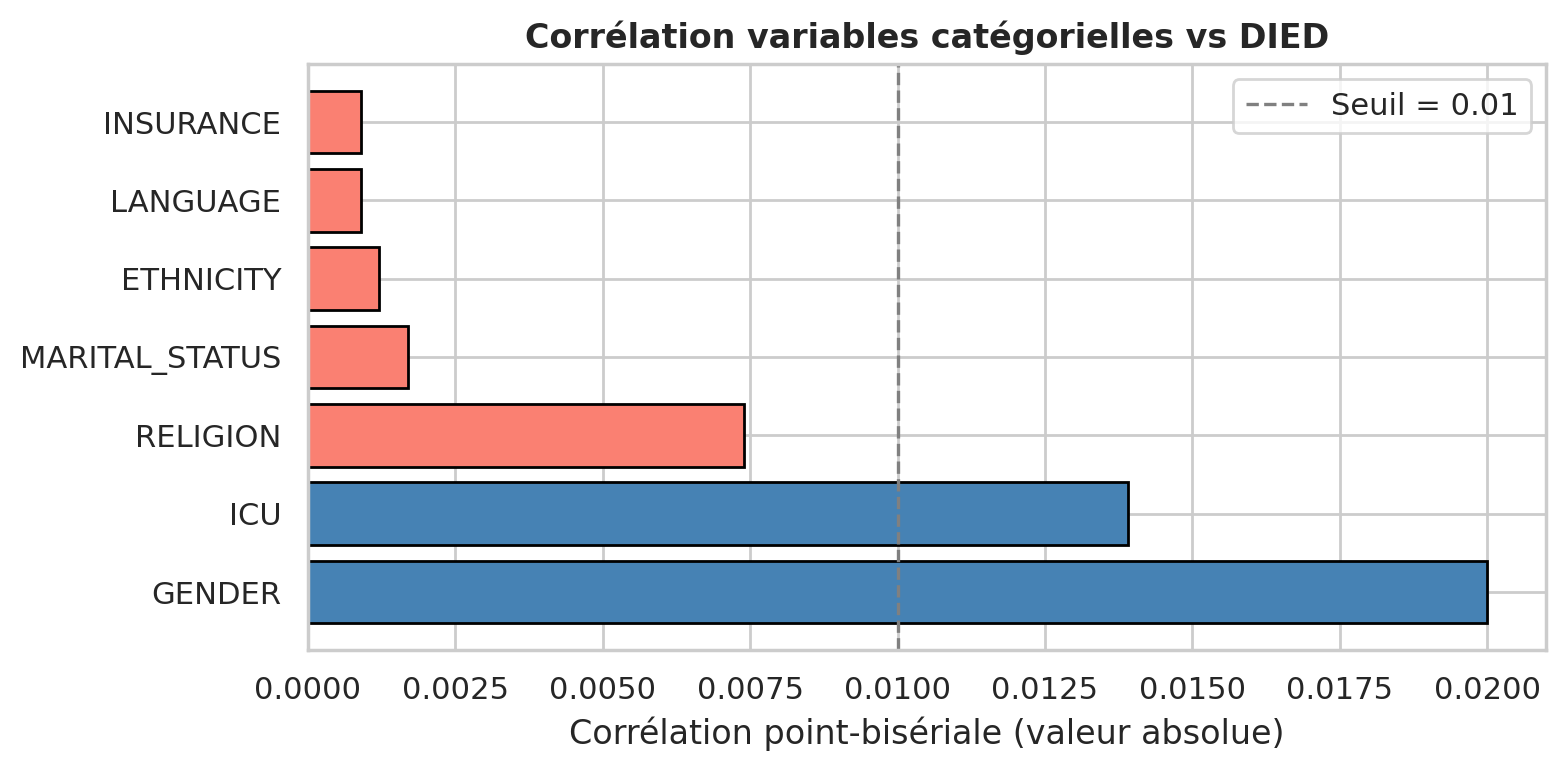

                correlation  p_value
GENDER                 0.02        0
ICU                  0.0139   0.0001
RELIGION             0.0074   0.0367
MARITAL_STATUS       0.0017    0.621
ETHNICITY            0.0012    0.744
LANGUAGE             0.0009    0.794
INSURANCE            0.0009    0.792


In [14]:
from scipy.stats import pointbiserialr

cat_cols = x_df.select_dtypes(include='object').columns.tolist()

cat_corr = {}
for col in cat_cols:
    encoded = x_df[col].astype('category').cat.codes
    corr, pval = pointbiserialr(encoded, ys)
    cat_corr[col] = {'correlation': round(abs(corr), 4), 'p_value': round(pval, 4)}

cat_corr_df = pd.DataFrame(cat_corr).T.sort_values('correlation', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue' if v >= 0.01 else 'salmon' for v in cat_corr_df['correlation']]
ax.barh(cat_corr_df.index, cat_corr_df['correlation'], color=colors, edgecolor='black')
ax.axvline(x=0.01, color='gray', linestyle='--', linewidth=1.2, label='Seuil = 0.01')
ax.set_xlabel('Corrélation point-bisériale (valeur absolue)')
ax.set_title('Corrélation variables catégorielles vs DIED', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(cat_corr_df.to_string())

**Résultats :**

| Variable | Corrélation | p-value | Décision |
|---|---|---|---|
| GENDER | 0.020 | 0.000 |  Conservée |
| ICU | 0.014 | 0.0001 |  Conservée |
| INSURANCE | 0.001 | 0.792 |  Conservée (justification clinique) |
| RELIGION | 0.007 | 0.037 |  Supprimée |
| MARITAL_STATUS | 0.002 | 0.621 |  Supprimée |
| ETHNICITY | 0.001 | 0.744 |  Supprimée |
| LANGUAGE | 0.001 | 0.794 | Supprimée |

**Justifications détaillées :**

- **GENDER** (corr=0.020, p~0) : signal statistiquement prouvé. Justification clinique : différences physiologiques hommes/femmes en soins intensifs. 

- **ICU** (corr=0.014, p=0.0001) : signal significatif. L'unité de soins (MICU, CSRU, SICU...) reflète directement la gravité du cas clinique. 

- **INSURANCE** (corr=0.001, p=0.792) : signal nul sur ce dataset synthétique, mais **conservée par justification clinique** : aux USA, le type d'assurance (Medicare, Medicaid, Self-Pay) est corrélé au statut socio-économique, lui-même lié à l'accès aux soins et à la mortalité hospitalière. Le GAN n'a pas reproduit cette corrélation, mais elle existe dans les vraies données MIMIC. 

- **RELIGION** (corr=0.007, p=0.037) : p-value légèrement significative (0.037 < 0.05) mais corrélation trop faible (0.007 < 0.01) pour être exploitable par le modèle. Aucune justification clinique directe avec la mortalité en soins intensifs. 

- **MARITAL_STATUS, ETHNICITY, LANGUAGE** : corrélations quasi nulles (<0.002) et p-values > 0.06 signal inexistant sur ces données, aucune justification clinique directe. 

### 3.4.2 Variables numériques et binaires

Variables numériques/binaires analysées : 157
Colonnes constantes exclues de l'analyse : 173

Top 20 variables les plus corrélées avec DIED :
                     correlation  p_value
RESP_RATE_MEAN_DAY1       0.0958        0
Adltrespfl                0.0908        0
RESP_RATE_MAX_DAY1        0.0906        0
RESP_RATE_MEAN_DAY2       0.0894        0
RESP_RATE_MAX_DAY2        0.0861        0
HR_MAX_DAY2               0.0735        0
HR_MAX_DAY1               0.0726        0
HR_MEAN_DAY2              0.0661        0
TEMP_MAX_DAY2             0.0651        0
HR_MIN_DAY1               0.0648        0
HR_MEAN_DAY1              0.0633        0
Coag/hemrdx               0.0553        0
DIAS_BP_MIN_DAY2           0.054        0
MEAN_BP_MIN_DAY2          0.0539        0
SYS_BP_MIN_DAY1           0.0493        0
Acrenlfail                0.0486        0
Hyperlipidem              0.0461        0
RESP_RATE_MIN_DAY1        0.0451        0
SYS_BP_MAX_DAY1            0.045        0
DIAS_BP_MIN_DAY1  

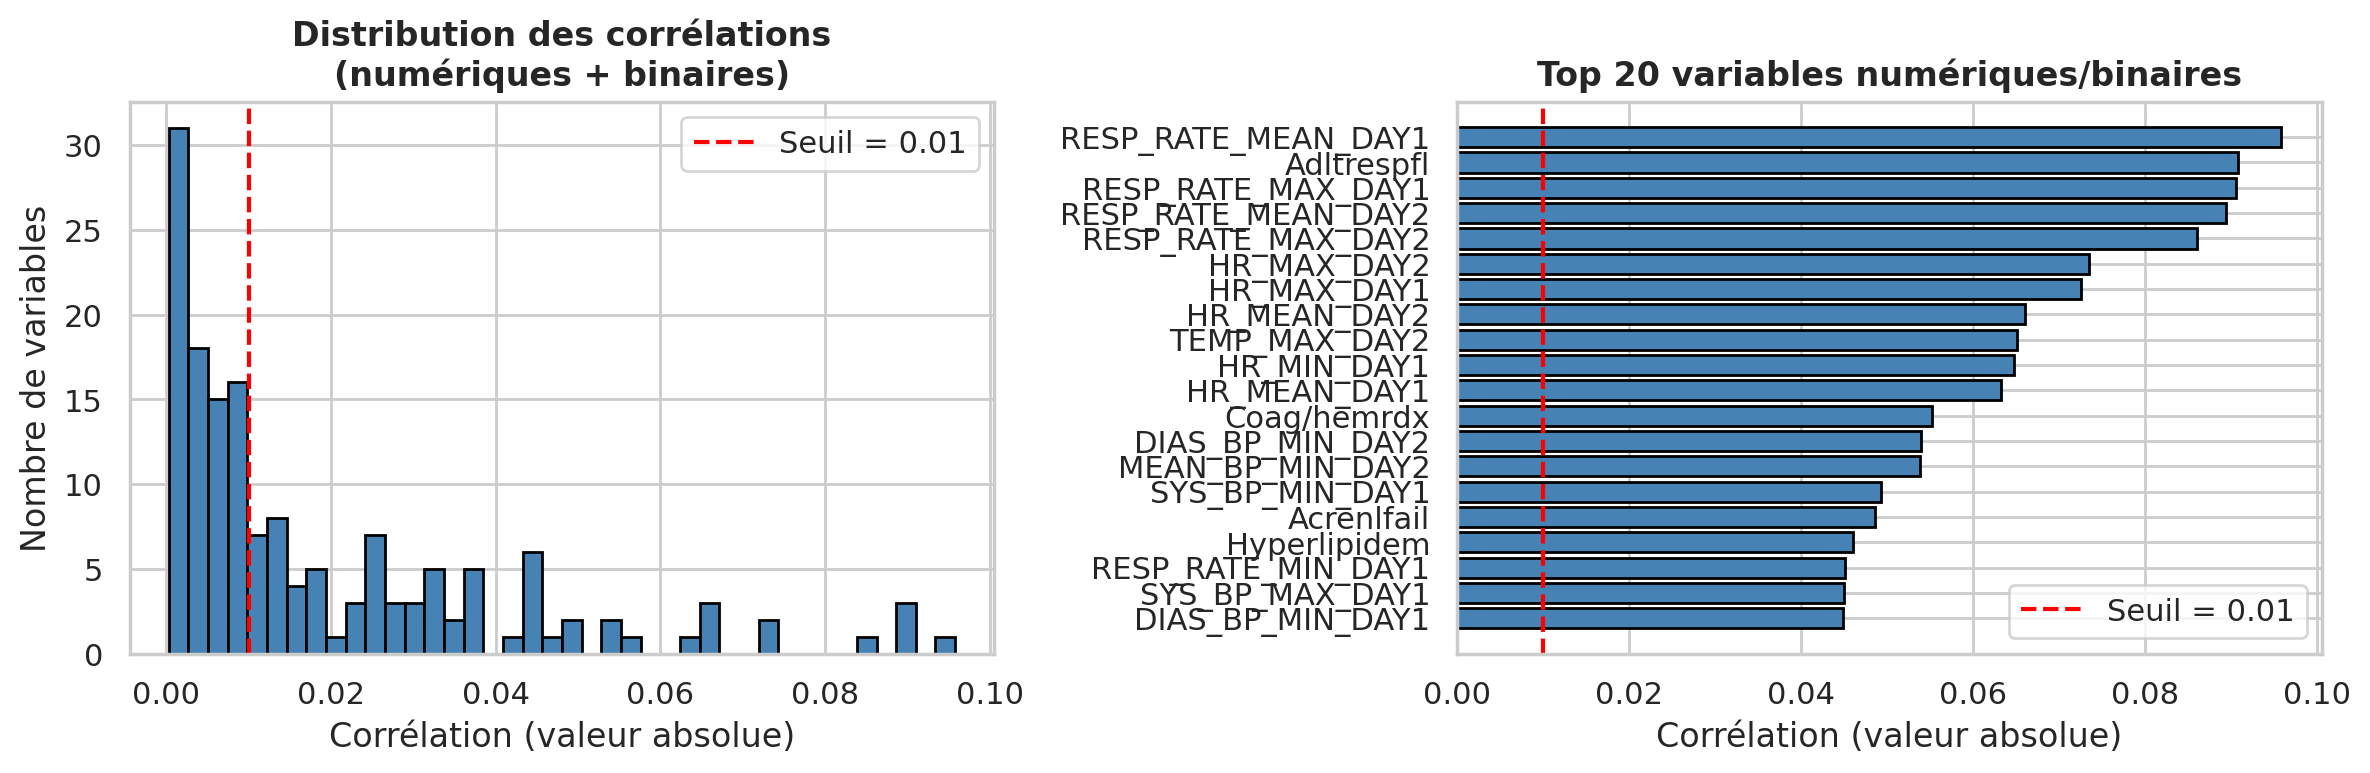

In [15]:
# Corrélation de toutes les variables numériques et binaires avec DIED
# But : analyse exploratoire,  identifier les variables les plus informatives
# On exclut les colonnes constantes (variance = 0), corrélation indéfinie

num_bin_cols = [
    col for col in x_df.select_dtypes(exclude='object').columns
    if x_df[col].nunique() > 1
]

print(f"Variables numériques/binaires analysées : {len(num_bin_cols)}")
print(f"Colonnes constantes exclues de l'analyse : "
      f"{x_df.select_dtypes(exclude='object').shape[1] - len(num_bin_cols)}")

num_corr = {}
for col in num_bin_cols:
    col_vals = x_df[col].fillna(x_df[col].median())
    corr, pval = pointbiserialr(col_vals, ys)
    num_corr[col] = {'correlation': round(abs(corr), 4), 'p_value': round(pval, 4)}

num_corr_df = pd.DataFrame(num_corr).T.sort_values('correlation', ascending=False)

print(f'\nTop 20 variables les plus corrélées avec DIED :')
print(num_corr_df.head(20).to_string())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(num_corr_df['correlation'].dropna(), bins=40,
             color='steelblue', edgecolor='black')
axes[0].axvline(x=0.01, color='red', linestyle='--', label='Seuil = 0.01')
axes[0].set_xlabel('Corrélation (valeur absolue)')
axes[0].set_ylabel('Nombre de variables')
axes[0].set_title('Distribution des corrélations\n(numériques + binaires)',
                  fontweight='bold')
axes[0].legend()

top20 = num_corr_df.head(20)
axes[1].barh(top20.index[::-1], top20['correlation'][::-1],
             color='steelblue', edgecolor='black')
axes[1].axvline(x=0.01, color='red', linestyle='--', label='Seuil = 0.01')
axes[1].set_xlabel('Corrélation (valeur absolue)')
axes[1].set_title('Top 20 variables numériques/binaires', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

**Interprétation — Variables numériques et binaires :**

La distribution des corrélations montre que la plupart des variables ont une corrélation faible avec `DIED` ce qui est attendu : aucune variable seule ne prédit le décès, c'est leur **combinaison** qui est informative.

Les variables avec corrélation < 0.01 comprennent de nombreuses comorbidités (Anémie, Diabète avec complications, Coma/lésion cérébrale, Cancer secondaire, etc.) et constantes vitales (TEMP_MEAN_DAY1, TEMP_MIN_DAY1) qui ont une **justification clinique forte** en soins intensifs.

**Décision : on ne supprime aucune variable numérique/binaire.** Leur faible corrélation individuelle sur ce dataset synthétique ne reflète pas leur utilité réelle, le GAN a pu ne pas reproduire fidèlement ces corrélations. La PCA qui suit se chargera de réduire la dimensionnalité en extrayant les combinaisons de variables les plus discriminantes.

### 3.4.3 Suppression finale des variables non pertinentes

Trois types de suppressions sont appliquées :

**1. Colonnes constantes (173 variables)**
Variables binaires dont la valeur est toujours 0 dans le dataset aucun patient ne présente ce diagnostic. Elles n'apportent strictement aucune information au modèle et sont supprimées systématiquement.

**2. Variables catégorielles non pertinentes (4 variables)**
RELIGION, MARITAL_STATUS, ETHNICITY, LANGUAGE, corrélation quasi nulle avec DIED et p-value > 0.05 sur ce dataset, sans justification clinique directe pour la mortalité en soins intensifs.

**3. Variables numériques/binaires non constantes : aucune suppression**
Toutes conservées pour leur pertinence clinique (comorbidités, constantes vitales). Leur corrélation individuelle faible sur ce dataset synthétique ne reflète pas leur utilité réelle, le GAN n'a pas fidèlement reproduit ces corrélations. La PCA gérera la réduction de dimensionnalité.

**Bilan :**

| Étape | Supprimées | Justification |
|---|---|---|
| Colonnes constantes | 173 | Valeur unique; aucune information |
| Catégorielles (corr + p-value) | 4 | Signal nul + pas de justification clinique |
| Numériques/binaires | 0 | Toutes cliniquement pertinentes |
| **Total supprimées** | **177** | sur 341 variables initiales |
| **Total conservées** | **164** | dont 3 catégorielles (GENDER, ICU, INSURANCE) |

In [16]:
#  1. Suppression des colonnes constantes (nunique == 1) ──
# Variables binaires toujours à 0 — aucune information pour le modèle
const_cols = [col for col in x_df.select_dtypes(exclude='object').columns
              if x_df[col].nunique() <= 1]
x_df.drop(columns=const_cols, inplace=True)
x_test_df.drop(columns=[c for c in const_cols if c in x_test_df.columns], inplace=True)
print(f'Colonnes constantes supprimées : {len(const_cols)}')

#  2. Suppression des variables catégorielles non pertinentes ──
# Critère : corrélation < 0.01 ET p-value > 0.05
# Exception : INSURANCE conservée — justification clinique
SEUIL_CORR = 0.01
SEUIL_PVAL = 0.05
KEEP_OVERRIDE = ['INSURANCE']

to_drop_cat = cat_corr_df[
    (cat_corr_df['correlation'] < SEUIL_CORR) |
    (cat_corr_df['p_value'] > SEUIL_PVAL)
].index.tolist()
to_drop_cat = [c for c in to_drop_cat if c not in KEEP_OVERRIDE]

x_df.drop(columns=to_drop_cat, inplace=True)
x_test_df.drop(columns=[c for c in to_drop_cat if c in x_test_df.columns], inplace=True)
cat_cols = [c for c in cat_cols if c not in to_drop_cat]

#  3. Variables numériques/binaires non constantes : aucune suppression
# Toutes représentent des comorbidités ou constantes vitales cliniquement pertinentes.
# Leur corrélation individuelle faible sur ce dataset synthétique (GAN) ne reflète
# pas leur utilité réelle. La PCA gérera la réduction de dimensionnalité.

print(f'Variables catégorielles supprimées ({len(to_drop_cat)}) : {to_drop_cat}')
print(f'Variables numériques/binaires supprimées : 0')
print(f'Variables catégorielles conservées : {cat_cols}')
print(f'Dimensions finales, Train : {x_df.shape}, Test : {x_test_df.shape}')

Colonnes constantes supprimées : 173
Variables catégorielles supprimées (4) : ['RELIGION', 'MARITAL_STATUS', 'ETHNICITY', 'LANGUAGE']
Variables numériques/binaires supprimées : 0
Variables catégorielles conservées : ['INSURANCE', 'GENDER', 'ICU']
Dimensions finales, Train : (79999, 160), Test : (20001, 160)


### 3.5 Distribution de quelques variables numériques clés

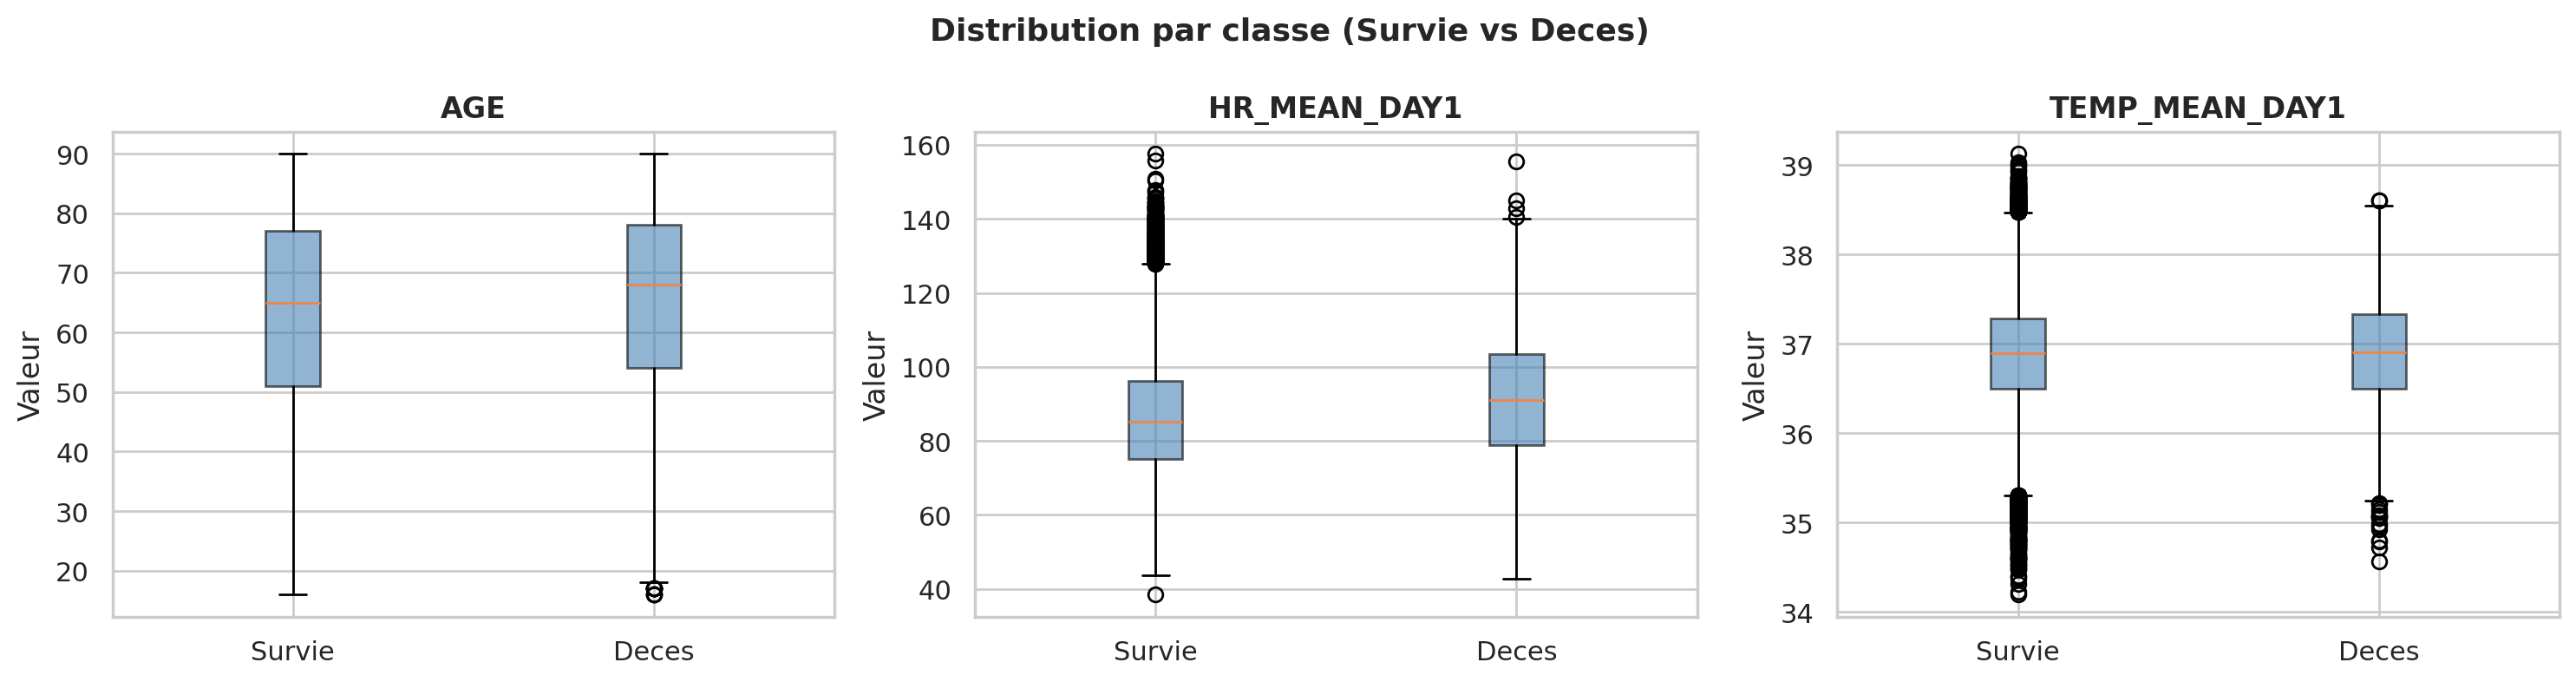

In [17]:
num_key = ["AGE", "HR_MEAN_DAY1", "TEMP_MEAN_DAY1", "GCS_MIN_DAY1"]
num_key_available = [c for c in num_key if c in x_df.columns]

if num_key_available:
    fig, axes = plt.subplots(1, len(num_key_available),
                              figsize=(5 * len(num_key_available), 4))
    if len(num_key_available) == 1:
        axes = [axes]
    for ax, col in zip(axes, num_key_available):
        data_0 = x_df.loc[ys == 0, col].dropna()
        data_1 = x_df.loc[ys == 1, col].dropna()
        ax.boxplot([data_0, data_1], tick_labels=["Survie", "Deces"],  # ← corrigé
                   patch_artist=True,
                   boxprops=dict(facecolor="steelblue", alpha=0.6))
        ax.set_title(col, fontweight="bold")
        ax.set_ylabel("Valeur")
    plt.suptitle("Distribution par classe (Survie vs Deces)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Variables numeriques cles non trouvees.")

Interprétation:
- AGE Médianes similaires (~65 ans): Les patients décédés ne sont pas systématiquement plus âgés, mourir jeune en USI reste possible (traumatismes, urgences);
- Fréquence cardiaque (HR_MEAN_DAY1): Aucune différence notable (~88-93 bpm). Un cœur qui bat vite ou lentement le jour J ne prédit pas seul le décès;
- Température (TEMP_MEAN_DAY1) : Distributions identiques (~37°C). Ni fièvre ni hypothermie marquée ne distingue les deux groupes sur la moyenne journalière.

CCL: Ces 3 signes vitaux du 1er jour sont insuffisants pour prédire la mortalité. C'est cohérent cliniquement : un patient peut sembler stable à J1 et décéder plus tard. C'est précisément pourquoi le modèle exploite 341 variables sur l'ensemble du séjour.

## 4. Préparation des données

### 4.1 Fusion des catégories rares

Après la sélection par corrélation, trois variables catégorielles sont conservées : **GENDER**, **ICU** et **INSURANCE**.

- **GENDER** : 2 modalités (M/F) pas de fusion nécessaire.
- **ICU** : 5 modalités (MICU, CSRU, SICU, CCU, TSICU) fusion des rares appliquée.
- **INSURANCE** : 5 modalités (Medicare, Private, Medicaid, Government, Self_Pay) fusion des rares appliquée pour éviter les problèmes d'encodage sur le jeu de test.

In [18]:
def merge_rare_categories(dfs, col, keep_n=5, other_label="OTHER"):
    """
    Regroupe les categories rares d'une colonne sous 'OTHER'.

    Parametres
    ----------
    dfs : list of DataFrame
        Liste [train, test] — les top-N categories sont apprises sur dfs[0].
    col : str
        Colonne a traiter.
    keep_n : int
        Nombre de categories les plus frequentes a conserver.
    other_label : str
        Etiquette de remplacement pour les categories rares.
    """
    top = dfs[0][col].value_counts().head(keep_n).index.tolist()
    for df in dfs:
        df[col] = df[col].where(df[col].isin(top), other_label)


# Seul ICU est conservé après la sélection par corrélation
# GENDER n'a que 2 modalités (M/F) — pas besoin de fusion
merge_rare_categories([x_df, x_test_df], col="ICU", keep_n=5)

print("Fusion des categories rares effectuee.")
for col in cat_cols:
    print(f"  {col} : {x_df[col].nunique()} modalites")

Fusion des categories rares effectuee.
  INSURANCE : 5 modalites
  GENDER : 2 modalites
  ICU : 6 modalites


In [19]:
# ICU et INSURANCE nécessitent une fusion des catégories rares
# GENDER n'a que 2 modalités (M/F) — pas de fusion nécessaire
merge_rare_categories([x_df, x_test_df], col='ICU',       keep_n=5)
merge_rare_categories([x_df, x_test_df], col='INSURANCE', keep_n=5)

print('Fusion des catégories rares effectuée.')
for col in cat_cols:
    print(f'  {col} : {x_df[col].nunique()} modalités')

Fusion des catégories rares effectuée.
  INSURANCE : 5 modalités
  GENDER : 2 modalités
  ICU : 6 modalités


La fusion des catégories rares a permis de réduire la complexité des variables catégorielles ICU et INSURANCE en regroupant les modalités peu fréquentes sous une catégorie 'OTHER'. Cela limite le surapprentissage, améliore la robustesse du modèle et réduit la dimension après encodage. La variable GENDER n’a pas nécessité de traitement en raison de son caractère binaire

### 4.2 Encodage des variables catégorielles

**A Label Encoding** (`pd.factorize`) : entier par catégorie. Compact mais introduit un ordre artificiel.

**B One-Hot Encoding** (`pd.get_dummies`) : une colonne binaire par modalité. Pas d'ordre artificiel, meilleure séparation linéaire. **Utilisé comme encodage principal.**

In [20]:
def label_encode(df_train, df_test):
    """
    Encode les variables categorielles par entier (factorize).
    Encodage appris sur df_train, applique a df_test.
    Categories inconnues dans df_test : codees -1.
    """
    char_cols = df_train.select_dtypes(include="object").columns
    for col in char_cols:
        codes, uniques = pd.factorize(df_train[col])
        df_train[col] = codes
        cat2code = {k: v for v, k in enumerate(uniques)}
        df_test[col] = df_test[col].map(cat2code).fillna(-1).astype(int)

In [21]:
# --- Encodage A : Label Encoding ---
x_fact_df      = x_df.copy()
x_test_fact_df = x_test_df.copy()
label_encode(x_fact_df, x_test_fact_df)

print(f"Label Encoding — Train : {x_fact_df.shape}, Test : {x_test_fact_df.shape}")
x_fact_df.head(3)

Label Encoding — Train : (79999, 160), Test : (20001, 160)


,INSURANCE,GENDER,AGE,HR_MIN_DAY1,HR_MAX_DAY1,HR_MEAN_DAY1,SYS_BP_MIN_DAY1,SYS_BP_MAX_DAY1,SYS_BP_MEAN_DAY1,DIAS_BP_MIN_DAY1,...,Epilepsy/cnv,Coma/brndmg,Retinaldx,Glaucoma,Othereyedx,Othnervdx,Hrtvalvedx,Carditis,HTN,Htncomplicn
0,0,0,21,57.2,109,70.8,79.8,120,94.4,26.9,...,0,0,0,0,0,0,0,0,0,0
1,0,1,39,79.3,121,96.9,94,139,114,38.6,...,0,0,0,0,0,0,0,0,0,1
2,1,1,40,118,175,141,123,144,135,67.8,...,0,0,0,0,0,0,0,0,0,0


In [22]:
# Encodage B : One-Hot Encoding 
# Encodage train + test ensemble pour garantir les memes colonnes
x_all = pd.concat([x_df, x_test_df], axis=0, keys=["train", "test"])
x_all_oh = pd.get_dummies(x_all, columns=cat_cols, drop_first=False)

x_oh_df      = x_all_oh.loc["train"].reset_index(drop=True)
x_test_oh_df = x_all_oh.loc["test"].reset_index(drop=True)

# Imputation des valeurs manquantes par la mediane (apprise sur train)
medians = x_oh_df.median()
x_oh_df.fillna(medians, inplace=True)
x_test_oh_df.fillna(medians, inplace=True)

print(f"One-Hot Encoding — Train : {x_oh_df.shape}, Test : {x_test_oh_df.shape}")
x_oh_df.head(3)

One-Hot Encoding — Train : (79999, 170), Test : (20001, 170)


,AGE,HR_MIN_DAY1,HR_MAX_DAY1,HR_MEAN_DAY1,SYS_BP_MIN_DAY1,SYS_BP_MAX_DAY1,SYS_BP_MEAN_DAY1,DIAS_BP_MIN_DAY1,DIAS_BP_MAX_DAY1,DIAS_BP_MEAN_DAY1,...,INSURANCE_Private,INSURANCE_Self_Pay,GENDER_F,GENDER_M,ICU_CCU,ICU_CSRU,ICU_MICU,ICU_OTHER,ICU_SICU,ICU_TSICU
0,21,57.2,109,70.8,79.8,120,94.4,26.9,68.9,48.7,...,True,False,True,False,False,False,False,False,True,False
1,39,79.3,121,96.9,94,139,114,38.6,74.3,66.6,...,True,False,False,True,True,False,False,False,False,False
2,40,118,175,141,123,144,135,67.8,83.3,80.4,...,False,False,False,True,False,False,True,False,False,False


Deux stratégies d’encodage ont été testées : un encodage par entiers (label encoding), simple mais introduisant un ordre artificiel, et un encodage one-hot, plus fidèle mais augmentant la dimensionnalité. L’encodage a été réalisé de manière cohérente entre les jeux d’entraînement et de test afin d’éviter les incohérences de variables. Une imputation des valeurs manquantes par la médiane a ensuite été appliquée pour garantir la compatibilité avec les modèles.

### 4.3 Séparation train / validation

Split stratifié **80 / 20** pour conserver le ratio de déséquilibre dans les deux ensembles.

In [23]:
x_train, x_valid, y_train, y_valid = model_selection.train_test_split(
    x_oh_df, ys,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=ys,
)

print(f"Train : {len(x_train):,} patients  |  Valid : {len(x_valid):,} patients")
print(f"  Deces train : {y_train.sum():,} ({y_train.mean():.1%})")
print(f"  Deces valid : {y_valid.sum():,} ({y_valid.mean():.1%})")

Train : 63,999 patients  |  Valid : 16,000 patients
  Deces train : 2,238 (3.5%)
  Deces valid : 559 (3.5%)


Les données ont été séparées en un ensemble d’entraînement (80 %) et un ensemble de validation (20 %) afin d’évaluer les performances du modèle sur des données non vues. Une stratification a été appliquée sur la variable cible afin de conserver la proportion de décès dans les deux ensembles, ce qui est essentiel compte tenu du fort déséquilibre des classes.

## 5. Modélisation

### 5.1 Suréchantillonnage (RandomOverSampler)

Appliqué **uniquement sur le train** pour éviter toute fuite de données vers la validation.

In [24]:
ros = RandomOverSampler(random_state=RANDOM_STATE)
x_resampled, y_resampled = ros.fit_resample(x_train, y_train)

print(f"Apres RandomOverSampler :")
print(f"  Train reequilibre : {x_resampled.shape}")
print(f"  Distribution : {pd.Series(y_resampled).value_counts().to_dict()}")

Apres RandomOverSampler :
  Train reequilibre : (123522, 170)
  Distribution : {0: 61761, 1: 61761}


Le jeu d’entraînement présentant un fort déséquilibre de classes (~3.5 % de décès), un sur-échantillonnage aléatoire a été appliqué afin d’équilibrer les classes. La classe minoritaire a été dupliquée jusqu’à obtenir une distribution 50/50, permettant au modèle d’apprendre correctement les caractéristiques associées aux décès. Cependant, cette méthode peut introduire un risque de surapprentissage en raison de la duplication des observations.

### 5.2 Normalisation et PCA

- **StandardScaler** : normalisation (moyenne 0, variance 1) obligatoire avant PCA.
- **PCA** : réduction de dimensionnalité, élimine le bruit et accélère l'entraînement.

> Le scaler et la PCA sont **ajustés sur le train uniquement** et appliqués au valid.

In [25]:
N_COMP = 20  # Valeur initiale optimisee par GridSearch en section 6

scaler = preprocessing.StandardScaler()
xs_train = scaler.fit_transform(x_resampled)
xs_valid = scaler.transform(x_valid)

pca = decomposition.PCA(n_components=N_COMP, random_state=RANDOM_STATE)
xp_train = pca.fit_transform(xs_train)
xp_valid = pca.transform(xs_valid)

print(f"PCA avec {N_COMP} composantes")
print(f"  Variance expliquee : {pca.explained_variance_ratio_.sum():.1%}")
print(f"  Shape train : {xp_train.shape}  |  Shape valid : {xp_valid.shape}")

PCA avec 20 composantes
  Variance expliquee : 34.4%
  Shape train : (123522, 20)  |  Shape valid : (16000, 20)


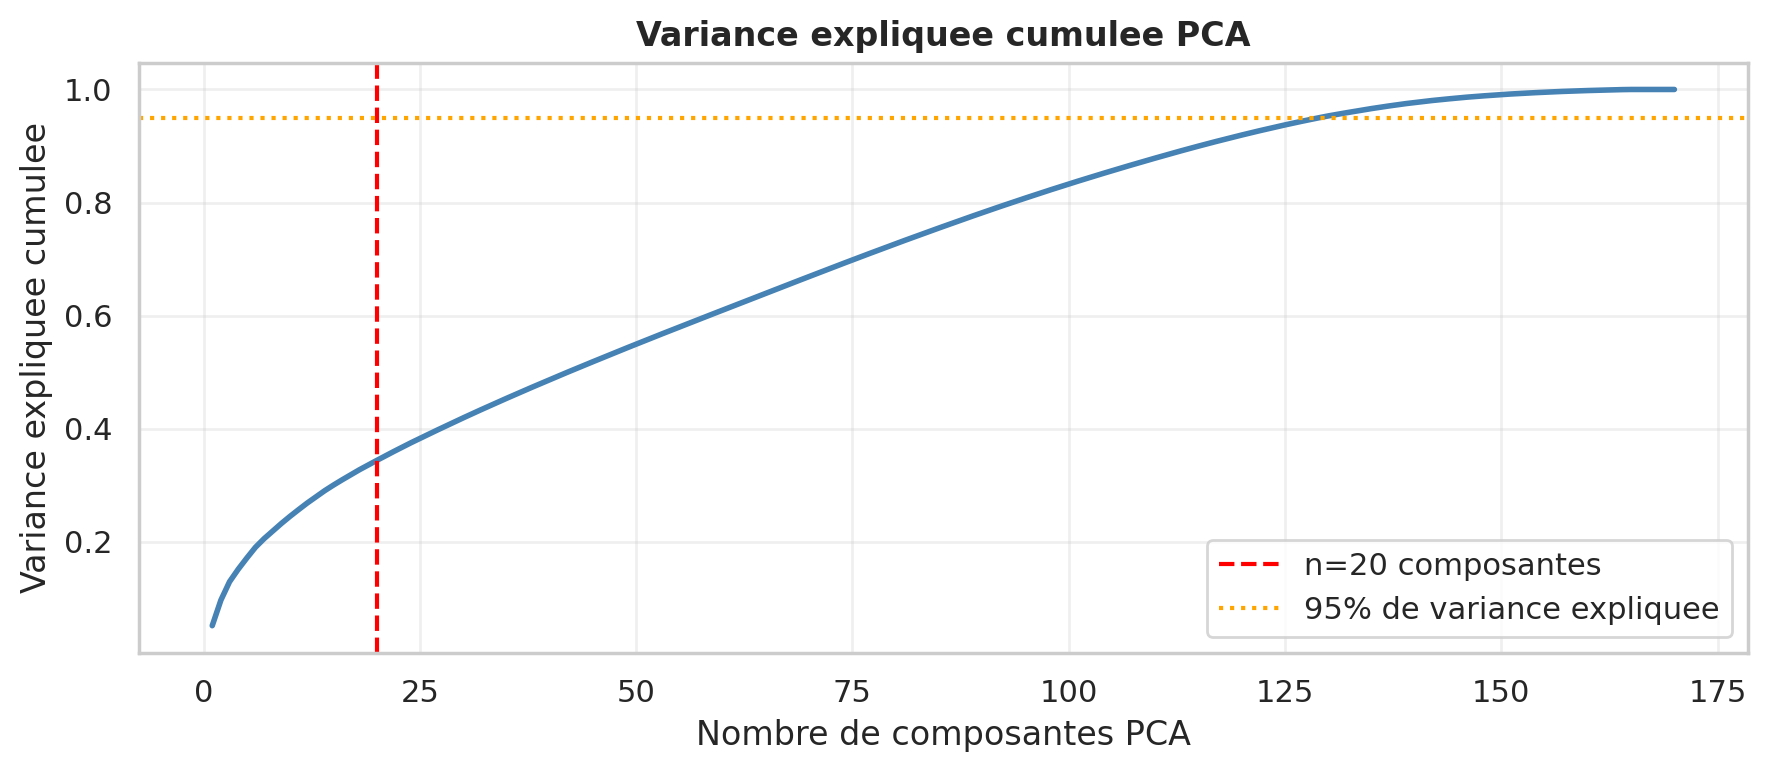

In [26]:
# Variance expliquee cumulee
pca_full = decomposition.PCA(random_state=RANDOM_STATE).fit(xs_train)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar, color="steelblue", linewidth=2)
ax.axvline(x=N_COMP, color="red",    linestyle="--", label=f"n={N_COMP} composantes")
ax.axhline(y=0.95,   color="orange", linestyle=":",  label="95% de variance expliquee")
ax.set_xlabel("Nombre de composantes PCA")
ax.set_ylabel("Variance expliquee cumulee")
ax.set_title("Variance expliquee cumulee PCA", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Une analyse de la variance expliquée cumulée a été réalisée afin d’évaluer le nombre de composantes nécessaires. Le choix de 20 composantes correspond à un compromis entre compression des données et conservation de l’information, bien que la variance expliquée reste partielle.


Le faible pourcentage de variance expliquée suggère que les données sont très multidimensionnelles et que l’information n’est pas concentrée sur quelques axes principaux.



### 5.3 Comparaison de modèles sans rééquilibrage

Pour illustrer l'impact du déséquilibre : sans ROS, tous les modèles ignorent la classe minoritaire.

In [27]:
sc_base  = preprocessing.StandardScaler()
pca_base = decomposition.PCA(n_components=N_COMP, random_state=RANDOM_STATE)
xp_train_base = pca_base.fit_transform(sc_base.fit_transform(x_train))
xp_valid_base = pca_base.transform(sc_base.transform(x_valid))

modeles_base = {
    "Logistic Regression" : linear_model.LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest"       : ensemble.RandomForestClassifier(n_estimators=10, random_state=RANDOM_STATE, n_jobs=-1),
    "Gaussian NB"         : naive_bayes.GaussianNB(),
    "KNN (k=5)"           : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

print("Resultats SANS reequilibrage (PCA n=20) :")
print(f"{'Modele':<22} {'Bal. Acc.':>10} {'Recall':>8}")
print("-" * 44)
for nom, mod in modeles_base.items():
    mod.fit(xp_train_base, y_train)
    yp = mod.predict(xp_valid_base)
    ba = metrics.balanced_accuracy_score(y_valid, yp)
    rc = metrics.recall_score(y_valid, yp)
    print(f"{nom:<22} {ba:>10.3f} {rc:>8.3f}")
print("-" * 44)
print("-> Recall ~ 0 : les modeles predisent tous 'Survie'.")

Resultats SANS reequilibrage (PCA n=20) :
Modele                  Bal. Acc.   Recall
--------------------------------------------
Logistic Regression         0.501    0.002
Random Forest               0.501    0.002
Gaussian NB                 0.514    0.034
KNN (k=5)                   0.499    0.000
--------------------------------------------
-> Recall ~ 0 : les modeles predisent tous 'Survie'.


### Interprétation Sans rééquilibrage


Tous les modèles ont un **recall quasi nul** : ils prédisent systématiquement la survie et ne détectent quasiment aucun décès. La balanced accuracy de ~0.50 est équivalente à un classifieur aléatoire.

Le **GaussianNB** se distingue légèrement (recall = 0.034) grâce à son hypothèse probabiliste qui lui permet de capturer un faible signal même sur des classes déséquilibrées, mais ce résultat reste inexploitable en pratique.

Avec 96.5% de survivants, tous les modèles apprennent qu'il est toujours rentable de prédire la survie. Le rééquilibrage est indispensable.

Les performances des modèles sans rééquilibrage montrent une balanced accuracy proche de 0.5 et un recall quasi nul, indiquant que les modèles prédisent majoritairement la classe dominante (survie). Cela met en évidence l’impact négatif du déséquilibre des classes et justifie l’utilisation de techniques de rééquilibrage comme le sur-échantillonnage.

### 5.4 Comparaison de modèles avec RandomOverSampler

In [28]:
modeles = {
    "Logistic Regression" : linear_model.LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest"       : ensemble.RandomForestClassifier(n_estimators=20, random_state=RANDOM_STATE, n_jobs=-1),
    "Gaussian NB"         : naive_bayes.GaussianNB(),
    "KNN (k=5)"           : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

resultats = {}

print(f"Resultats AVEC RandomOverSampler + PCA (n={N_COMP}) :")
print(f"{'Modele':<22} {'Bal. Acc.':>10} {'Recall':>8} {'Precision':>10}")
print("-" * 54)

for nom, mod in modeles.items():
    mod.fit(xp_train, y_resampled)
    yp = mod.predict(xp_valid)
    ba = metrics.balanced_accuracy_score(y_valid, yp)
    rc = metrics.recall_score(y_valid, yp)
    pr = metrics.precision_score(y_valid, yp, zero_division=0)
    resultats[nom] = {"balanced_accuracy": ba, "recall": rc, "precision": pr, "model": mod}
    print(f"{nom:<22} {ba:>10.3f} {rc:>8.3f} {pr:>10.3f}")

print("-" * 54)
best_name = max(resultats, key=lambda k: resultats[k]["balanced_accuracy"])
print(f"\n-> Meilleur : {best_name} (Bal. Acc. = {resultats[best_name]['balanced_accuracy']:.3f})")

Resultats AVEC RandomOverSampler + PCA (n=20) :
Modele                  Bal. Acc.   Recall  Precision
------------------------------------------------------
Logistic Regression         0.696    0.689      0.078
Random Forest               0.502    0.004      0.286
Gaussian NB                 0.661    0.558      0.079
KNN (k=5)                   0.552    0.175      0.082
------------------------------------------------------

-> Meilleur : Logistic Regression (Bal. Acc. = 0.696)


### Interprétation Avec RandomOverSampler

Le rééquilibrage des classes modifie fortement les performances par rapport à la situation initiale.
Contrairement à la baseline, les modèles sont désormais capables de détecter la classe minoritaire (décès), comme en témoigne l’augmentation significative du recall.

La **régression logistique** apparaît comme le meilleur modèle, avec une balanced accuracy de 0.696 et un recall de 0.689, ce qui signifie qu’environ 69 % des décès sont correctement identifiés.

Cependant, **la précision reste faible (~0.078)** : parmi les patients prédits comme décédés, une grande proportion correspond en réalité à des survivants. Cela traduit un nombre important de faux positifs.
Dans un contexte médical, ce compromis peut être acceptable, car le coût d’un faux négatif (ne pas détecter un patient à risque) est généralement plus critique qu’un faux positif.

Le **Gaussian Naive Bayes** obtient des performances correctes (balanced accuracy = 0.661, recall = 0.558), mais reste inférieur à la régression logistique. Cela peut s’expliquer par les hypothèses fortes du modèle (indépendance des variables) qui sont rarement vérifiées dans des données médicales complexes.

Le **KNN** présente des performances limitées (recall = 0.175), probablement en raison de la difficulté de cette méthode à gérer des données de grande dimension et transformées par PCA.

Le **Random Forest** (avec seulement 20 arbres) reste très peu performant (recall ~ 0.004). Ce résultat suggère que le modèle ne parvient pas à exploiter efficacement les données après transformation (PCA + sur-échantillonnage). Le nombre d’arbres est probablement insuffisant et la réduction de dimension peut avoir supprimé des interactions utiles pour ce type de modèle.

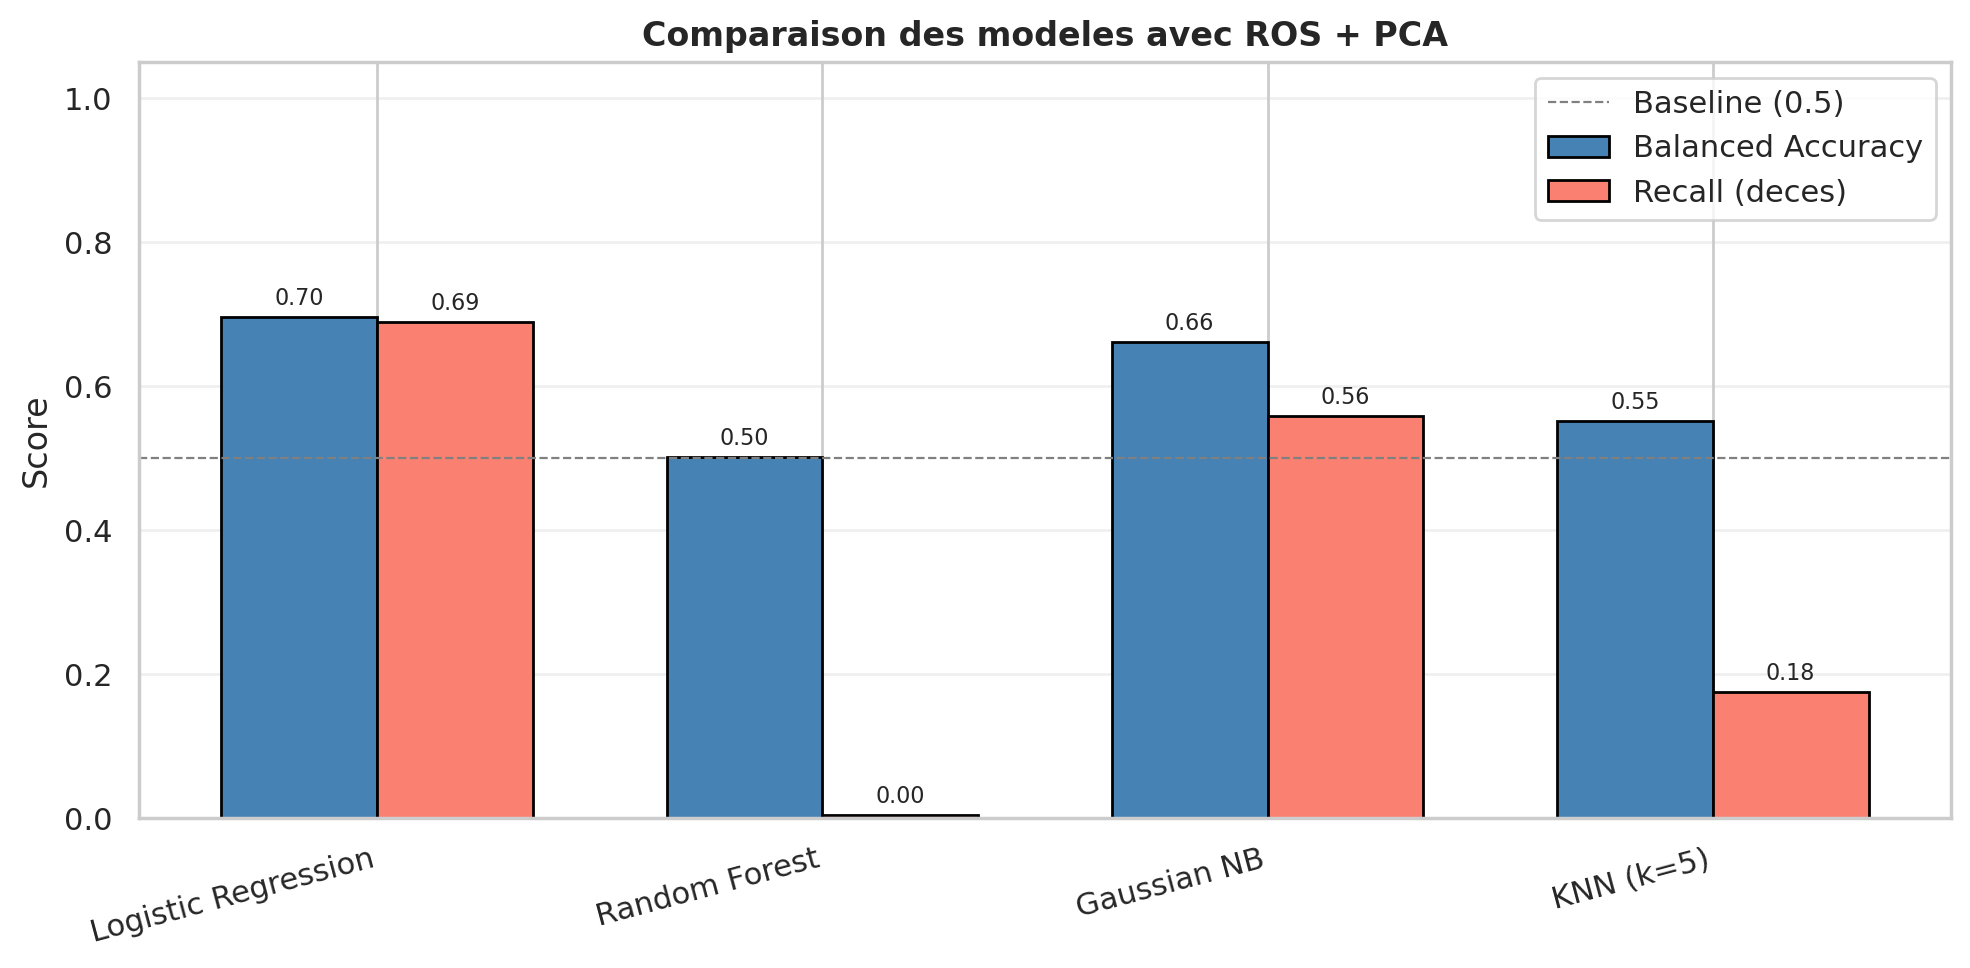

In [29]:
noms = list(resultats.keys())
ba_scores = [resultats[n]["balanced_accuracy"] for n in noms]
rc_scores = [resultats[n]["recall"] for n in noms]

x_idx = np.arange(len(noms))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x_idx - width/2, ba_scores, width, label="Balanced Accuracy",
            color="steelblue", edgecolor="black")
b2 = ax.bar(x_idx + width/2, rc_scores, width, label="Recall (deces)",
            color="salmon",    edgecolor="black")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Baseline (0.5)")
ax.set_xticks(x_idx)
ax.set_xticklabels(noms, rotation=15, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Comparaison des modeles avec ROS + PCA", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

Le rééquilibrage permet enfin de détecter les décès, mais la régression logistique est le seul modèle vraiment performant dans cette configuration.

## 6. Évaluations

### 6.1 Validation croisée + GridSearchCV

On utilise une **validation croisée k-fold** combinée à `GridSearchCV` pour sélectionner le nombre optimal de composantes PCA de façon rigoureuse.

In [30]:
CV      = 5
SCORING = "balanced_accuracy"
param_grid = {"pca__n_components": [1, 2, 5, 10, 20, 30, 40, 60]}

# Échantillon stratifié pour alléger la mémoire
x_sample, _, y_sample, _ = model_selection.train_test_split(
    x_oh_df, ys,
    train_size=30_000,
    random_state=RANDOM_STATE,
    stratify=ys,
)

# Suréchantillonnage sur l'échantillon uniquement
ros_cv = RandomOverSampler(random_state=RANDOM_STATE)
x_res_all, y_res_all = ros_cv.fit_resample(x_sample, y_sample)

print(f"Train rééquilibré (CV) : {x_res_all.shape}")
print(f"Distribution : {pd.Series(y_res_all).value_counts().to_dict()}")

Train rééquilibré (CV) : (57902, 170)
Distribution : {0: 28951, 1: 28951}


In [31]:
# Pipeline : StandardScaler -> PCA -> GaussianNB
pipe = pipeline.Pipeline([
    ("scaler", preprocessing.StandardScaler()),
    ("pca",    decomposition.PCA(random_state=RANDOM_STATE)),
    ("model",  naive_bayes.GaussianNB()),
])

search = model_selection.GridSearchCV(
    pipe, param_grid,
    cv=CV, scoring=SCORING,
    n_jobs=1,   # séquentiel pour éviter le crash mémoire
    verbose=1,
)
search.fit(x_res_all, y_res_all)

best_n_comp = search.best_params_["pca__n_components"]
print(f"\nMeilleur score CV ({SCORING}) : {search.best_score_:.4f}")
print(f"Meilleurs parametres : {search.best_params_}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Meilleur score CV (balanced_accuracy) : 0.6722
Meilleurs parametres : {'pca__n_components': 10}


 n_components  mean_bal_acc     std  rank
           10         0.672 0.00117     1
           20         0.656 0.00292     2
            5         0.652 0.00186     3
           30         0.626  0.0144     4
           40         0.615   0.015     5
            2         0.606 0.00262     6
            1         0.519 0.00299     7
           60         0.504  0.0032     8


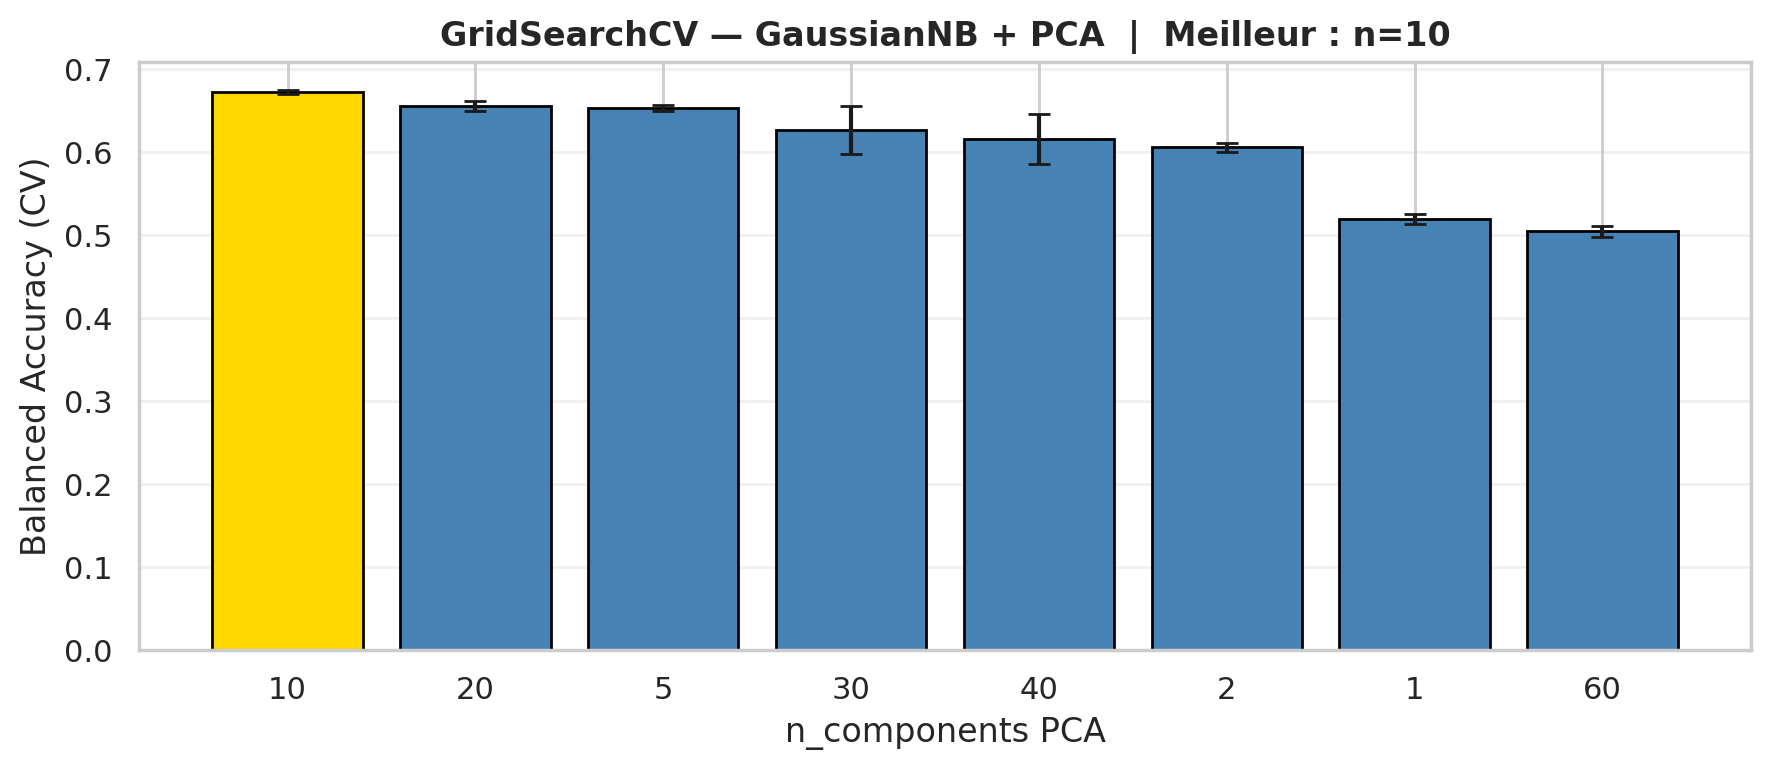

In [32]:
# Résultats complets du GridSearch
cv_res = pd.DataFrame(search.cv_results_)[[
    "param_pca__n_components",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]].sort_values("rank_test_score")
cv_res.columns = ["n_components", "mean_bal_acc", "std", "rank"]
print(cv_res.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
n_vals  = cv_res["n_components"].values.astype(int)
means   = cv_res["mean_bal_acc"].values
stds    = cv_res["std"].values
colors_bar = ["gold" if n == best_n_comp else "steelblue" for n in n_vals]
ax.bar(range(len(n_vals)), means, yerr=2*stds,
       color=colors_bar, edgecolor="black", capsize=4)
ax.set_xticks(range(len(n_vals)))
ax.set_xticklabels([str(n) for n in n_vals])
ax.set_xlabel("n_components PCA")
ax.set_ylabel("Balanced Accuracy (CV)")
ax.set_title(f"GridSearchCV — GaussianNB + PCA  |  Meilleur : n={best_n_comp}",
             fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Interprétation GridSearchCV

Après réduction de dimension, le modèle atteint ses meilleures performances pour n = 10 composantes (balanced accuracy ~ 0.672).
Cela indique qu’un nombre modéré de composantes suffit à capturer l’information utile pour la prédiction.

L’écart entre n = 10 (0.672) et n = 20 (0.656) ou n = 5 (0.652) reste relativement faible, ce qui suggère que les performances sont stables autour de cet optimum.
Un nombre trop faible de composantes entraîne une perte d’information, tandis qu’un nombre trop élevé dégrade les performances en introduisant du bruit.

### 6.2 Validation croisée GaussianNB vs Logistic Regression

Validation croisee 5-fold | n_components=10

Modele                  Moyenne    Std
--------------------------------------
GaussianNB               0.6722 0.0012
LogisticRegression       0.6660 0.0017
--------------------------------------


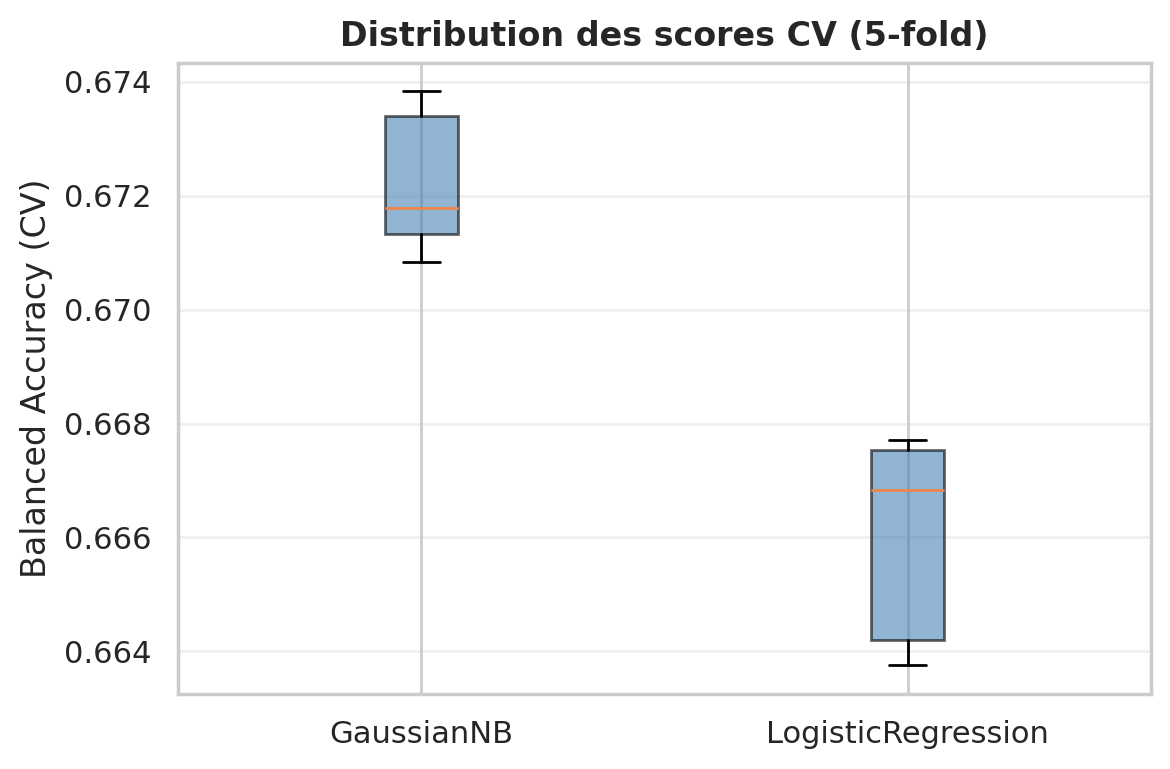

In [33]:
modeles_cv = {
    "GaussianNB"         : naive_bayes.GaussianNB(),
    "LogisticRegression" : linear_model.LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
}

all_scores = {}

print(f"Validation croisee {CV}-fold | n_components={best_n_comp}\n")
print(f"{'Modele':<22} {'Moyenne':>8} {'Std':>6}")
print("-" * 38)

for nom, mod in modeles_cv.items():
    p = pipeline.Pipeline([
        ("scaler", preprocessing.StandardScaler()),
        ("pca",    decomposition.PCA(n_components=best_n_comp, random_state=RANDOM_STATE)),
        ("model",  mod),
    ])
    scores = model_selection.cross_val_score(
        p, x_res_all, y_res_all,
        cv=CV, scoring=SCORING,
        n_jobs=1,   # ← corrigé
    )
    all_scores[nom] = scores
    print(f"{nom:<22} {scores.mean():>8.4f} {scores.std():>6.4f}")

print("-" * 38)

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(list(all_scores.values()), tick_labels=list(all_scores.keys()),
           patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.6))
ax.set_ylabel("Balanced Accuracy (CV)")
ax.set_title(f"Distribution des scores CV ({CV}-fold)", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Interprétation Validation croisée GaussianNB vs Logistic Regression


Le **GaussianNB** est légèrement meilleur que la Logistic Regression en validation croisée, avec une balanced accuracy moyenne de 0.672 contre 0.666.

Il est aussi un peu plus stable, avec un écart-type plus faible (0.0012 contre 0.0017), ce qui signifie que ses performances varient moins d’un fold à l’autre.

L’écart entre les deux modèles reste toutefois faible (+0.006), ce qui montre que les deux approches sont globalement proches en termes de performance.

Le fait que GaussianNB fonctionne légèrement mieux ici peut s’expliquer par l’utilisation de la PCA avec 10 composantes, qui transforme les variables initiales en nouvelles composantes non corrélées. Cette transformation rend les données plus compatibles avec les hypothèses du modèle, notamment l’idée d’une relative indépendance entre variables.


CCL: La validation croisée montre que GaussianNB obtient les meilleures performances avec une bonne stabilité, bien que la différence avec la régression logistique reste faible, indiquant des modèles globalement comparables.


### 6.3 Évaluation finale sur le jeu de validation

In [34]:
best_pipe = search.best_estimator_
best_pipe.fit(x_resampled, y_resampled)
y_pred_final = best_pipe.predict(x_valid)

ba = metrics.balanced_accuracy_score(y_valid, y_pred_final)
rc = metrics.recall_score(y_valid, y_pred_final)
pr = metrics.precision_score(y_valid, y_pred_final, zero_division=0)
f1 = metrics.f1_score(y_valid, y_pred_final)

print(f" Evaluation finale GaussianNB + PCA(n={best_n_comp}) + ROS")
print(f"  Balanced Accuracy : {ba:.4f}")
print(f"  Recall (deces)    : {rc:.4f}")
print(f"  Precision         : {pr:.4f}")
print(f"  F1-Score          : {f1:.4f}")

 Evaluation finale GaussianNB + PCA(n=10) + ROS
  Balanced Accuracy : 0.6669
  Recall (deces)    : 0.6351
  Precision         : 0.0709
  F1-Score          : 0.1276


 Interprétation Évaluation finale

> **Note** : cette évaluation concerne le modèle **GaussianNB + PCA (n=10) + RandomOverSampler**, sélectionné via GridSearch sur un échantillon de 30k patients.

Le modèle détecte **63.5 % des décès** (**recall = 0.635**), ce qui constitue une **amélioration majeure** par rapport à la situation sans rééquilibrage (**recall ~ 0**).

La **precision de 0.071** reste très faible : pour **1 décès correctement détecté, environ 13 à 14 survivants** sont également classés à tort comme “décès”.  
Ce comportement est typique des problèmes déséquilibrés et peut être **acceptable en contexte médical**, où **rater un décès (faux négatif)** est plus critique que générer des **faux positifs**.

Le **F1-score de 0.128** est faible, ce qui s’explique par le déséquilibre entre **recall élevé** et **precision faible**. Cette situation est inhérente au problème, la classe positive représentant seulement **~ 3.5 %** des observations.

La **balanced accuracy (~ 0.667)** confirme que le modèle est capable de **distinguer correctement les deux classes**, avec des performances nettement supérieures au hasard.


CCL :Le modèle final est **efficace pour détecter les patients à risque (recall élevé)**, mais au prix d’un **nombre important de faux positifs**.  
Ce compromis est cohérent avec l’objectif du projet et les contraintes des données déséquilibrées.


### 6.4 Matrice de confusion

- **VP** : décès correctement détectés -> objectif principal
- **FN** : décès non détectés -> erreur la plus grave cliniquement
- **FP** : survivants classés décédés -> sur-alerte
- **VN** : survivants bien classés

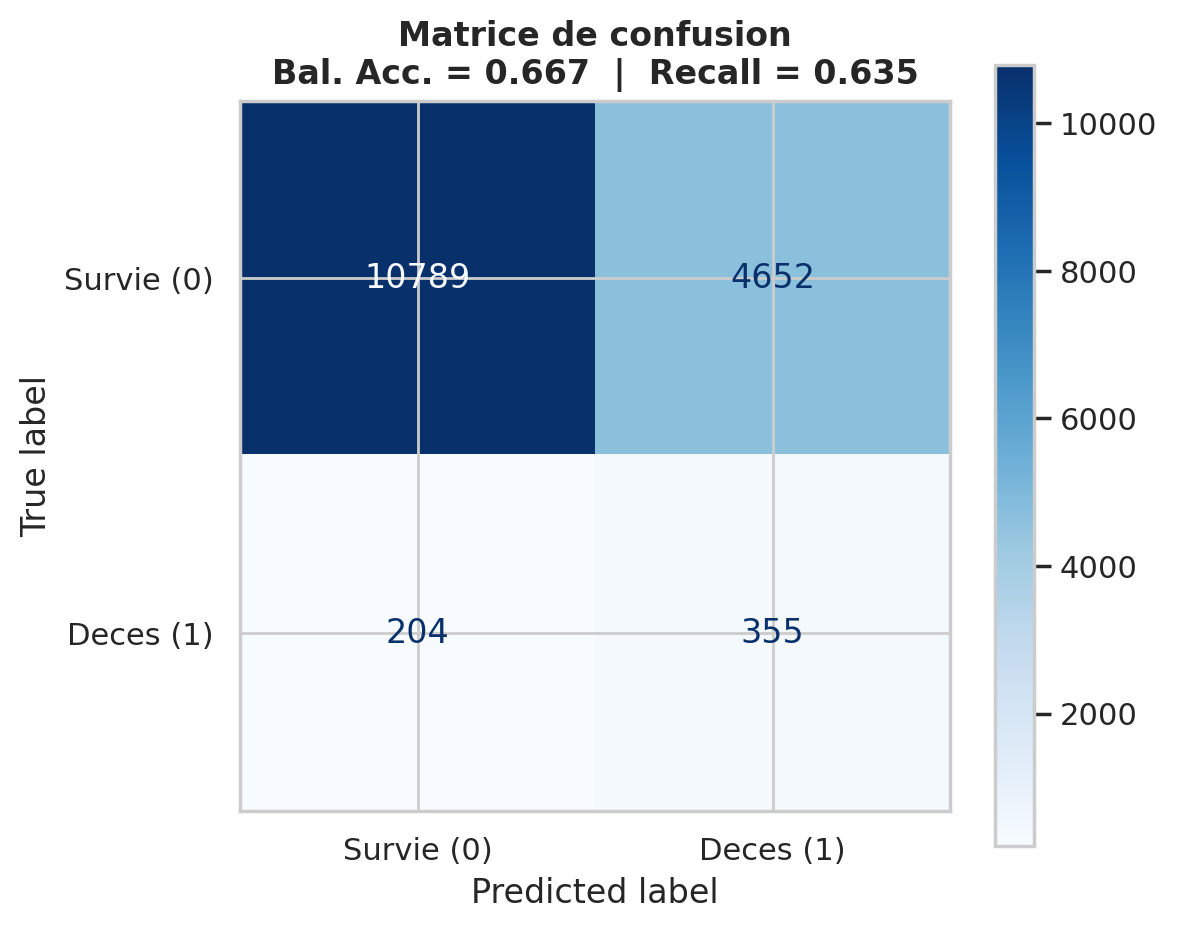

VN : 10,789  |  FP : 4,652
FN : 204  |  VP : 355  <- deces correctement detectes


In [35]:
fig, ax = plt.subplots(figsize=(6, 5))
disp = metrics.ConfusionMatrixDisplay.from_predictions(
    y_valid, y_pred_final,
    display_labels=["Survie (0)", "Deces (1)"],
    cmap=plt.cm.Blues,
    ax=ax,
)
ax.set_title(f"Matrice de confusion\nBal. Acc. = {ba:.3f}  |  Recall = {rc:.3f}",
             fontweight="bold")
plt.tight_layout()
plt.show()

cm = disp.confusion_matrix
print(f"VN : {cm[0,0]:,}  |  FP : {cm[0,1]:,}")
print(f"FN : {cm[1,0]:,}  |  VP : {cm[1,1]:,}  <- deces correctement detectes")

### Interprétation Matrice de confusion

- **355 décès détectés** sur 559 (**recall = 63.5%**) : près des deux tiers des patients à risque sont correctement identifiés.
- **204 décès manqués (FN)** : erreur critique, ces patients ne seraient pas détectés comme à risque. C’est l’erreur la plus grave en contexte médical.
- **4 652 faux positifs (FP)** : sur-alerte importante, des patients survivants sont classés à tort comme “décès”.

Le modèle est biaisé vers la **sensibilité (recall élevé) au détriment de la précision**, ce qui est cohérent avec l’objectif médical : **mieux vaut sur-surveiller que manquer un décès**.


### 6.5 Courbe ROC et AUC

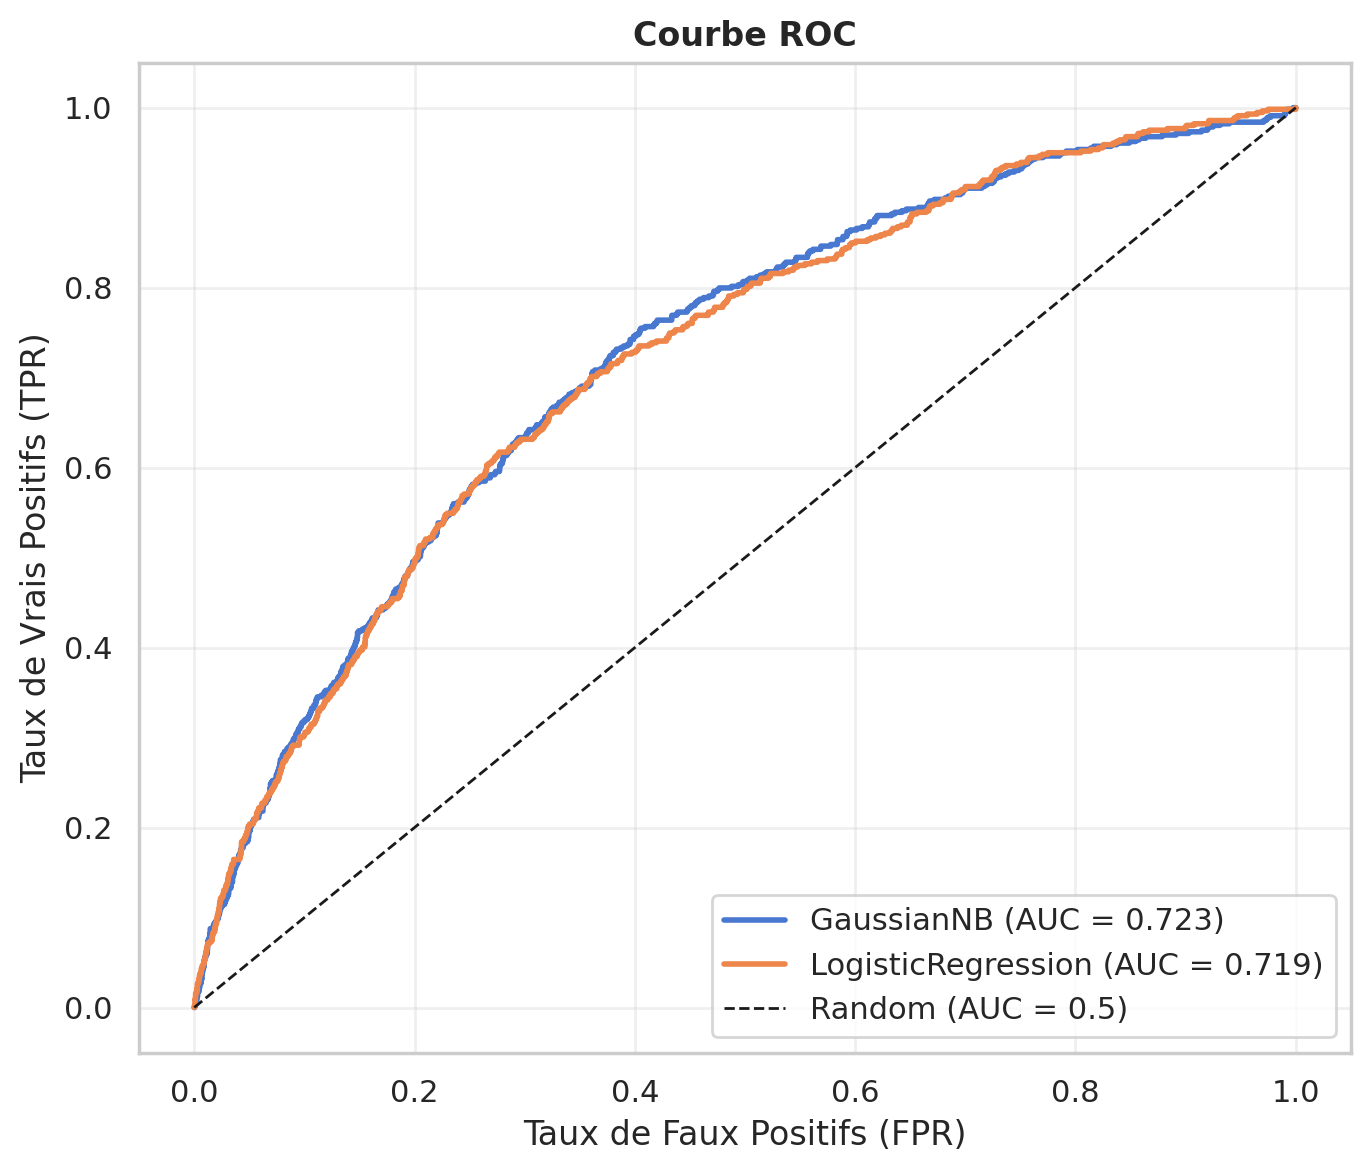

In [36]:
fig, ax = plt.subplots(figsize=(7, 6))

for nom, mod in modeles_cv.items():
    p = pipeline.Pipeline([
        ("scaler", preprocessing.StandardScaler()),
        ("pca",    decomposition.PCA(n_components=best_n_comp, random_state=RANDOM_STATE)),
        ("model",  mod),
    ])
    p.fit(x_resampled, y_resampled)
    y_scores = p.predict_proba(x_valid)[:, 1]
    fpr, tpr, _ = metrics.roc_curve(y_valid, y_scores)
    auc = metrics.roc_auc_score(y_valid, y_scores)
    ax.plot(fpr, tpr, linewidth=2, label=f"{nom} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC = 0.5)")
ax.set_xlabel("Taux de Faux Positifs (FPR)")
ax.set_ylabel("Taux de Vrais Positifs (TPR)")
ax.set_title("Courbe ROC", fontweight="bold")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Les deux modèles sont **très proches** :

- GaussianNB : **AUC = 0.723**
- Logistic Regression : **AUC = 0.719**

L’écart est **négligeable**, les modèles ont une **capacité de discrimination similaire** (~ 72 %).

L’AUC mesure le *ranking* (indépendant du seuil), alors que la **balanced accuracy** évalue le modèle au seuil 0.5 (métrique du projet).

On utilise la courbe ROC pour **évaluer globalement le modèle indépendamment du seuil**.



Malgré une bonne AUC, les performances restent limitées par le **déséquilibre des classes**, ce qui motive l’utilisation de méthodes plus avancées comme **SMOTE**.

## 7. Amélioration : SMOTE

### Qu'est-ce que le suréchantillonnage ?

Le **suréchantillonnage** augmente le nombre d'exemples de la classe minoritaire pour rééquilibrer les classes :

- **RandomOverSampler** : duplique aléatoirement des exemples existants de la classe minoritaire.
- **SMOTE** *(Synthetic Minority Oversampling Technique)* : génère de **nouveaux exemples synthétiques** en interpolant entre un exemple minoritaire et ses k plus proches voisins. Plus riche que la simple duplication.

**Utilité ici** : avec 3.5% de décès, sans rééquilibrage tous les modèles prédisent systématiquement la survie (recall = 0 sur la classe 1). Le rééquilibrage permet d'améliorer drastiquement le recall sur les décès.

In [37]:
smote = SMOTE(random_state=RANDOM_STATE)
x_smote, y_smote = smote.fit_resample(x_train, y_train)

sc_sm  = preprocessing.StandardScaler()
pca_sm = decomposition.PCA(n_components=best_n_comp, random_state=RANDOM_STATE)
xp_smote = pca_sm.fit_transform(sc_sm.fit_transform(x_smote))
xp_v_sm  = pca_sm.transform(sc_sm.transform(x_valid))

model_sm = naive_bayes.GaussianNB()
model_sm.fit(xp_smote, y_smote)
yp_sm = model_sm.predict(xp_v_sm)

ba_sm = metrics.balanced_accuracy_score(y_valid, yp_sm)
rc_sm = metrics.recall_score(y_valid, yp_sm)

print("Comparaison ROS vs SMOTE (GaussianNB + PCA) :")
print(f"  RandomOverSampler -> Bal. Acc. = {ba:.4f}  |  Recall = {rc:.4f}")
print(f"  SMOTE             -> Bal. Acc. = {ba_sm:.4f}  |  Recall = {rc_sm:.4f}")

Comparaison ROS vs SMOTE (GaussianNB + PCA) :
  RandomOverSampler -> Bal. Acc. = 0.6669  |  Recall = 0.6351
  SMOTE             -> Bal. Acc. = 0.5322  |  Recall = 0.3631


In [38]:
# Pipeline imblearn : SMOTE correctement integre dans la CV (pas de data leakage)
pipe_smote = imblearn.pipeline.Pipeline([
    ("scale",    preprocessing.StandardScaler()),
    ("pca",      decomposition.PCA(n_components=best_n_comp, random_state=RANDOM_STATE)),
    ("resample", SMOTE(random_state=RANDOM_STATE)),
    ("model",    naive_bayes.GaussianNB()),
])

scores_smote = model_selection.cross_val_score(
    pipe_smote, x_sample, y_sample,  # <- x_sample au lieu de x_oh_df (30k lignes)
    cv=CV, scoring=SCORING,
    n_jobs=1,                         # <- séquentiel
)

print(f"CV {CV}-fold avec SMOTE integre dans le pipeline :")
print(f"  Scores : {np.round(scores_smote, 3)}")
print(f"  Moyenne : {scores_smote.mean():.4f} +/- {scores_smote.std():.4f}")

CV 5-fold avec SMOTE integre dans le pipeline :
  Scores : [0.632 0.612 0.659 0.655 0.629]
  Moyenne : 0.6373 +/- 0.0174


### Interprétation ROS vs SMOTE

Les résultats montrent que **RandomOverSampler (ROS) reste supérieur à SMOTE** dans ce projet.

- **ROS (CV)** : ~ **0.672** (stable, std faible)
- **SMOTE (CV)** : ~ **0.637** (plus faible, std plus élevé ~ 0.017)

ROS donne donc de **meilleures performances et une meilleure stabilité**.
Le **SMOTE intégré correctement dans la validation croisée** donne une estimation fiable, mais reste **moins performant** que ROS.

Deux raisons principales peuvent expliquer cette sous-performance avec **GaussianNB** :

1. **Données binaires (0/1)** :  
   SMOTE génère des points par interpolation (ex : 0.3, 0.7), ce qui peut produire des **valeurs non réalistes** pour certaines variables médicales.

2. **Hypothèse du GaussianNB** :  
   Le modèle suppose des **distributions gaussiennes**.  
   SMOTE modifie la structure des données en ajoutant des points artificiels, ce qui peut **dégrader ces distributions**.


CCL: **ROS reste la meilleure stratégie de rééquilibrage dans cette configuration** :

- plus performant  
- plus stable  
- mieux adapté au modèle GaussianNB  

SMOTE pourrait être plus pertinent avec des modèles **non paramétriques** (Random Forest, XGBoost), capables de mieux exploiter des données synthétiques.

## 8. Conclusion et perspectives

### Meilleur résultat

| Approche | Balanced Accuracy |
|---|---|
| Sans rééquilibrage | ~0.50 (recall~ 0) |
| ROS + GaussianNB + PCA (n=10) | ~0.667 (hold-out) |
| ROS + GaussianNB + PCA (n=10) | **0.672 (CV 5-fold)** |
| SMOTE + GaussianNB + PCA (CV intégré) | 0.637 ± 0.017 |

---

### Ce qui a fonctionné

- Le **rééquilibrage par ROS** est indispensable : sans lui, recall ~ 0 sur tous les modèles.
- La **sélection de variables** a permis de supprimer des variables non informatives (constantes et catégorielles peu pertinentes), réduisant le bruit.
- Le **GaussianNB avec PCA (n=10)** est le meilleur modèle en validation croisée (**0.672**), avec de bonnes performances et une forte stabilité.
- La **PCA optimisée (n=10)** permet un bon compromis entre réduction de dimension et performance.
- **Pipeline sans data leakage** : scaler, PCA et rééquilibrage correctement intégrés.

---

### Ce qui n'a pas fonctionné

- **Random Forest (n=20)** : recall quasi nul, incapable de capter la classe minoritaire.
- **KNN** : performances faibles et sensibilité à la dimension.
- **SMOTE + GaussianNB** : performances inférieures à ROS (0.637 vs 0.672) et plus instables.

---

### Méthode de sélection des hyperparamètres

`GridSearchCV` avec validation croisée 5-fold et score `balanced_accuracy` sur un sous-échantillon stratifié de 30 000 patients (contrainte mémoire), pour optimiser le nombre de composantes PCA.

---

### Avec plus de temps

- Tester des modèles plus puissants (**XGBoost / LightGBM**) avec gestion native du déséquilibre.
- Tester `class_weight='balanced'` dans LogisticRegression pour éviter le sur-échantillonnage.
- Optimiser d’autres hyperparamètres (ex : nombre d’arbres pour Random Forest).
- Augmenter la taille de l’échantillon pour le GridSearch (actuellement limité à 30k).
- Explorer des méthodes alternatives de rééquilibrage et de calibration des probabilités.

## 9. Enregistrement des prédictions

> Soumettez le fichier ZIP sur [le site du challenge](https://codalab.lisn.upsaclay.fr/competitions/3739) via `Participate > Submit/View Results > Submit`.

In [39]:
# Entraînement final sur TOUTES les données d'entraînement
# Modèle retenu : GaussianNB (meilleur CV 5-fold ~ 0.672, légèrement supérieur à LogisticRegression ~ 0.666)

ros_final = RandomOverSampler(random_state=RANDOM_STATE)
x_all_res, y_all_res = ros_final.fit_resample(x_oh_df, ys)

final_pipe = pipeline.Pipeline([
    ('scaler', preprocessing.StandardScaler()),
    ('pca',    decomposition.PCA(n_components=best_n_comp, random_state=RANDOM_STATE)),
    ('model',  naive_bayes.GaussianNB()),
])

final_pipe.fit(x_all_res, y_all_res)

predictions = final_pipe.predict(x_test_oh_df)

print(f'Modele final : GaussianNB + PCA(n={best_n_comp}) + ROS')
print(f'Entraine sur {x_all_res.shape[0]:,} exemples.')
print(f'Predictions : {len(predictions):,}')
print(f'Distribution : {pd.Series(predictions).value_counts().to_dict()}')

Modele final : GaussianNB + PCA(n=10) + ROS
Entraine sur 154,404 exemples.
Predictions : 20,001
Distribution : {0: 13810, 1: 6191}


In [40]:
# Sauvegarde au format ZIP pour soumission Codalab
PRED_PATH.mkdir(parents=True, exist_ok=True)

t_stamp       = datetime.now().strftime("%Y-%m-%dT%H-%M-%S")
submission_fp = PRED_PATH / f"submission_{t_stamp}.zip"

pred_fname  = "mimic_synthetic_test.csv"
compr_opts  = dict(method="zip", archive_name=pred_fname)

pd.Series(predictions).to_csv(
    submission_fp, compression=compr_opts, index=False, header=False
)

print(f"Soumission prete : {submission_fp}")

Soumission prete : Submissions/submission_2026-03-29T08-38-32.zip


---

# Remarque sur le jeu de données

Les données ne contiennent pas d'informations médicales réelles. Elles ont été générées par un **GAN Wasserstein** pour préserver la confidentialité des patient·e·s.

Référence : [Privacy Preserving Synthetic Health Data](https://hal.inria.fr/hal-02160496/document) Andrew Yale, Saloni Dash, Ritik Dutta, Isabelle Guyon, Adrien Pavao, Kristin Bennett.

---